# PHẦN 2: Phân Tích Dữ Liệu Khám Phá (EDA)

## 1. Set up

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PALETTE = sns.color_palette('muted')
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

def load(name, parse_dates=None):
    return pd.read_csv(f'dataset/{name}.csv', parse_dates=parse_dates, low_memory=False)

products    = load('products')
customers   = load('customers',   parse_dates=['signup_date'])
orders      = load('orders',      parse_dates=['order_date'])
order_items = load('order_items')
promotions  = load('promotions',  parse_dates=['start_date','end_date'])
payments    = load('payments')
shipments   = load('shipments',   parse_dates=['ship_date','delivery_date'])
returns     = load('returns',     parse_dates=['return_date'])
reviews     = load('reviews',     parse_dates=['review_date'])
inventory   = load('inventory',   parse_dates=['snapshot_date'])
web_traffic = load('web_traffic', parse_dates=['date'])
geography   = load('geography')

# - Bảng phái sinh dùng chung -
order_items = order_items.assign(
    line_rev = lambda x: x['unit_price'] * x['quantity'] - x['discount_amount']
)
order_rev = (
    order_items
    .groupby('order_id')
    .agg(revenue=('line_rev','sum'),
         items=('quantity','sum'),
         discount=('discount_amount','sum'))
    .reset_index()
)
orders_full = (
    orders
    .merge(order_rev, on='order_id', how='left')
    .merge(geography[['zip','region']], on='zip', how='left')
)
orders_full = orders_full[orders_full['order_status'] != 'Cancelled']

monthly_rev = (
    orders_full
    .set_index('order_date')
    .resample('ME')[['revenue','order_id']]
    .agg(revenue=('revenue','sum'), orders=('order_id','count'))
    .assign(aov=lambda x: x['revenue'] / x['orders'])
)

products['margin_pct'] = (products['price'] - products['cogs']) / products['price']

In [9]:
# Phân loại New / Returning
first_order = orders_full.groupby('customer_id')['order_date'].min().rename('first_order_date')
orders_seg = orders_full.merge(first_order, on='customer_id')
orders_seg['segment'] = np.where(
    orders_seg['order_date'] == orders_seg['first_order_date'],
    'Khách mới', 'Khách quay lại'
)

seg_monthly = (
    orders_seg
    .set_index('order_date')
    .groupby([pd.Grouper(freq='ME'), 'segment'])['revenue']
    .sum()
    .unstack('segment')
    .fillna(0)
)
cus_seg = orders_seg.merge(customers, on='customer_id')

## 2. KPI Tổng Quan

In [10]:
total_rev    = orders_full['revenue'].sum()
total_orders = orders_full.shape[0]
total_custs  = customers.shape[0]
aov          = total_rev / total_orders
ret_rate     = returns['order_id'].nunique() / orders.shape[0]
avg_rating   = reviews['rating'].mean()
total_profit   = (order_items['line_rev'] - order_items['quantity'] * products.set_index('product_id')['cogs']).sum()
profit_margin   = total_profit / total_rev *100

kpis = {
    'Tổng doanh thu'     : f'{total_rev:,.0f}',
    'Tổng đơn hàng'      : f'{total_orders:,}',
    'Tổng khách hàng'    : f'{total_custs:,}',
    'AOV (Giá trị ĐH TB)': f'{aov:,.0f}',
    'Tỷ lệ hoàn trả'     : f'{ret_rate:.1%}',
    'Rating TB'          : f'{avg_rating:.2f}/5',
    'Tổng lợi nhuận thuần'    : f'{total_profit:,.0f}',
    'Biên lợi nhuận thuần'   : f'{profit_margin:.2%}',
}


for k, v in kpis.items():
    print(f'{k:<22}: {v:>12}')

Tổng doanh thu        : 15,680,869,265
Tổng đơn hàng         :      646,945
Tổng khách hàng       :      121,930
AOV (Giá trị ĐH TB)   :       24,238
Tỷ lệ hoàn trả        :         5.6%
Rating TB             :       3.94/5
Tổng lợi nhuận thuần  :   16,070,256
Biên lợi nhuận thuần  :       10.25%


## 3. Xu Hướng Doanh Thu & Đơn Hàng Theo Tháng

Tháng cao điểm  : [5, 4, 6]
Tháng thấp điểm : [12, 11, 1]


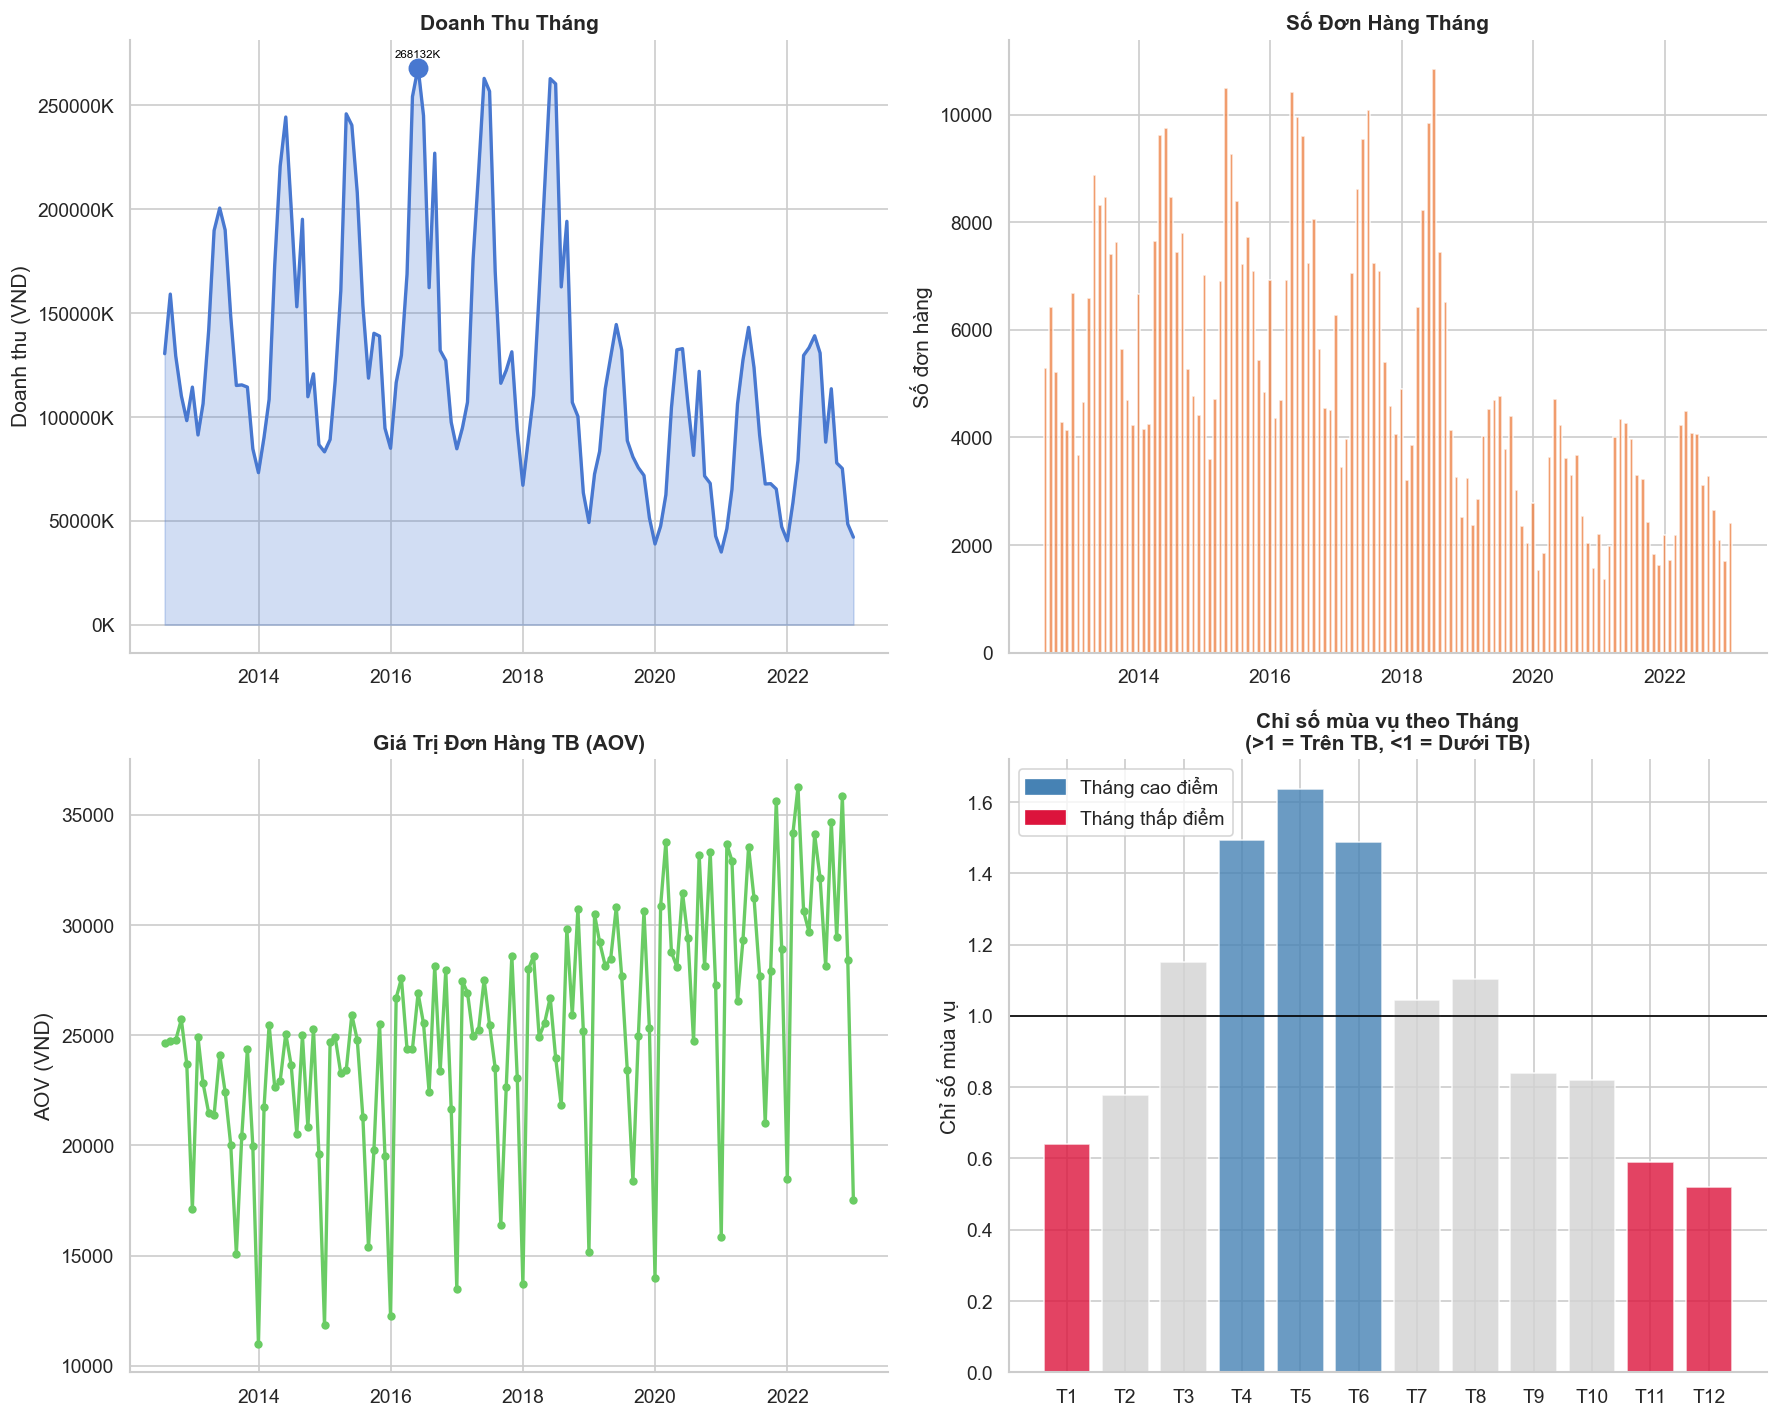

In [11]:
# Seasonality index = tháng TB / tổng TB
monthly_rev['month'] = monthly_rev.index.month
monthly_rev['year']  = monthly_rev.index.year
seasonal_idx = (
    monthly_rev.groupby('month')['revenue'].mean() /
    monthly_rev['revenue'].mean()
)

top_months = seasonal_idx.nlargest(3).index.tolist()
low_months = seasonal_idx.nsmallest(3).index.tolist()
print(f'Tháng cao điểm  : {top_months}')
print(f'Tháng thấp điểm : {low_months}')

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Revenue
axes[0,0].fill_between(monthly_rev.index, monthly_rev['revenue'],
                       alpha=0.25, color=PALETTE[0])
axes[0,0].plot(monthly_rev.index, monthly_rev['revenue'],
               color=PALETTE[0], linewidth=2)
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
axes[0,0].set_ylabel('Doanh thu (VND)')
axes[0,0].set_title('Doanh Thu Tháng', fontweight='bold')
for i, (d, v) in enumerate(monthly_rev['revenue'].items()):
    if v == monthly_rev['revenue'].max():
        axes[0,0].scatter(d, v, s=120, color=PALETTE[0], zorder=5)
        axes[0,0].annotate(f'{v/1e3:.0f}K', (d, v),
                         textcoords='offset points', xytext=(0,6),
                         ha='center', fontsize=7, color='black')

# Orders
axes[0,1].bar(monthly_rev.index, monthly_rev['orders'],
              width=20, color=PALETTE[1], alpha=0.8)
axes[0,1].set_ylabel('Số đơn hàng')
axes[0,1].set_title('Số Đơn Hàng Tháng', fontweight='bold')

# AOV 
axes[1,0].plot(monthly_rev.index, monthly_rev['aov'],
               color=PALETTE[2], linewidth=2, marker='o', markersize=4)
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}'))
axes[1,0].set_ylabel('AOV (VND)')
axes[1,0].set_title('Giá Trị Đơn Hàng TB (AOV)', fontweight='bold')

# Seasonality index 
colors = []
for month in seasonal_idx.index:
    if month in top_months:
        colors.append('steelblue')
    elif month in low_months:
        colors.append('crimson')
    else:
        colors.append('lightgray')
axes[1,1].bar(range(1,13), seasonal_idx.values, color=colors, alpha=0.8)
axes[1,1].axhline(1.0, color='black', linestyle='-', linewidth=1)
axes[1,1].set_xticks(range(1,13))
axes[1,1].set_xticklabels(['T1','T2','T3','T4','T5','T6',
                           'T7','T8','T9','T10','T11','T12'])
axes[1,1].set_title('Chỉ số mùa vụ theo Tháng\n(>1 = Trên TB, <1 = Dưới TB)',
                    fontweight='bold')
axes[1,1].set_ylabel('Chỉ số mùa vụ')
axes[1,1].legend(handles=[
    mpatches.Patch(color='steelblue', label='Tháng cao điểm'),
    mpatches.Patch(color='crimson', label='Tháng thấp điểm')
], loc='upper left')

plt.tight_layout()
plt.show()


Mặc dù cả doanh thu lẫn lượng đơn đều giảm nhưng AOV vẫn tăng, có thể do nhiều đơn hàng có giá trị lớn hơn.

In [12]:
monthly_rev['revenue']
yr1218 = monthly_rev['revenue'].loc[monthly_rev['revenue'].index.year < 2019].mean()
yr1922 = monthly_rev['revenue'].loc[monthly_rev['revenue'].index.year >= 2019].mean()
print(f'TB 1 tháng trong giai đoạn 2012-2018: {yr1218:,.0f} VND')
print(f'TB 1 tháng trong giai đoạn 2019-2022: {yr1922:,.0f} VND') 
print(f'Tăng trưởng TB 1 tháng năm 2019-2022 so với 2012-2018: {(yr1922/yr1218-1):.2%}')

TB 1 tháng trong giai đoạn 2012-2018: 147,264,742 VND
TB 1 tháng trong giai đoạn 2019-2022: 87,379,571 VND
Tăng trưởng TB 1 tháng năm 2019-2022 so với 2012-2018: -40.66%


In [13]:
yr1218 = monthly_rev['orders'].loc[monthly_rev['orders'].index.year < 2019].mean()
yr1922 = monthly_rev['orders'].loc[monthly_rev['orders'].index.year >= 2019].mean()
print(f'TB 1 tháng trong giai đoạn 2012-2018: {yr1218:,.0f}')
print(f'TB 1 tháng trong giai đoạn 2019-2022: {yr1922:,.0f}') 
print(f'Tăng trưởng TB 1 tháng năm 2019-2022 so với 2012-2018: {(yr1922/yr1218-1):.2%}')

TB 1 tháng trong giai đoạn 2012-2018: 6,409
TB 1 tháng trong giai đoạn 2019-2022: 3,063
Tăng trưởng TB 1 tháng năm 2019-2022 so với 2012-2018: -52.22%


In [14]:
yearly_aov = monthly_rev.resample('Y')['aov'].mean()
yearly_aov

order_date
2012-12-31    23447.613184
2013-12-31    20665.158985
2014-12-31    22046.712681
2015-12-31    21728.298227
2016-12-31    24370.773797
2017-12-31    23787.744715
2018-12-31    25532.424973
2019-12-31    25957.893116
2020-12-31    28732.817374
2021-12-31    28899.055812
2022-12-31    30920.122515
Freq: YE-DEC, Name: aov, dtype: float64

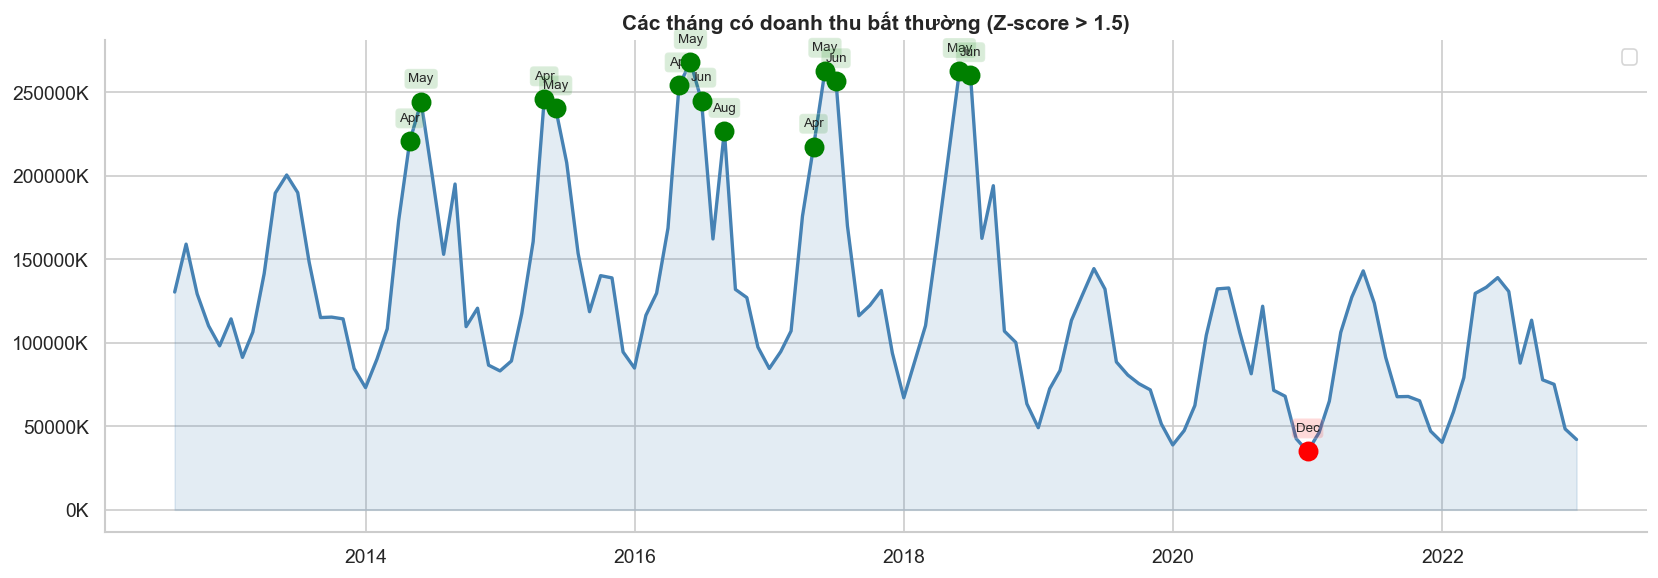


Các tháng bất thường:
                 revenue  orders           aov             type   z_score
order_date                                                               
2014-04-30  2.206425e+08    9627  22919.135986  ▲ Đột biến tăng  1.677512
2014-05-31  2.443095e+08    9744  25072.818383  ▲ Đột biến tăng  2.090250
2015-04-30  2.458423e+08   10502  23409.093510  ▲ Đột biến tăng  2.116980
2015-05-31  2.403847e+08    9273  25923.076266  ▲ Đột biến tăng  2.021803
2016-04-30  2.541533e+08   10426  24376.872711  ▲ Đột biến tăng  2.261918
2016-05-31  2.681319e+08    9965  26907.364136  ▲ Đột biến tăng  2.505696
2016-06-30  2.449944e+08    9595  25533.551848  ▲ Đột biến tăng  2.102194
2016-08-31  2.269003e+08    8065  28133.944113  ▲ Đột biến tăng  1.786643
2017-04-30  2.174093e+08    8619  25224.420390  ▲ Đột biến tăng  1.621127
2017-05-31  2.629088e+08    9553  27521.076715  ▲ Đột biến tăng  2.414610
2017-06-30  2.566675e+08   10078  25468.101296  ▲ Đột biến tăng  2.305765
2018-05-31  2.6

In [15]:
from datetime import datetime
# Z-score để phát hiện tháng doanh thu bất thường
rev_z = stats.zscore(monthly_rev['revenue'])
anomalies = monthly_rev[np.abs(rev_z) > 1.5].copy()
anomalies['z_score'] = rev_z[np.abs(rev_z) > 1.5]
anomalies['type'] = anomalies['z_score'].apply(lambda z: '▲ Đột biến tăng' if z > 0 else '▼ Đột biến giảm')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_rev.index, monthly_rev['revenue'], color='steelblue', linewidth=2)
ax.fill_between(monthly_rev.index, monthly_rev['revenue'], alpha=0.15, color='steelblue')

# Đánh dấu bất thường
for idx, row in anomalies.iterrows():
    color = 'red' if row['z_score'] < 0 else 'green'
    ax.scatter(idx, row['revenue'], s=120, color=color, zorder=5)
    ax.annotate(
        f"{datetime.strftime(idx, '%b')}",
        (idx, row['revenue']),
        textcoords='offset points', xytext=(0, 12),
        ha='center', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc=color, alpha=0.15)
    )

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.set_title('Các tháng có doanh thu bất thường (Z-score > 1.5)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nCác tháng bất thường:')
print(anomalies[['revenue','orders','aov','type','z_score']].to_string())

Doanh thu có tính mùa vụ, cao điểm vào tháng 4-6 (chu ky xuân hè mạnh). Tất cả các tháng đột biến tăng (chấm xanh) đều rơi vào tháng 4, 5, 6 - xác nhận mùa vụ, nhưng cũng cho thấy có yếu tố khuếch đại (campaign lớn hoặc sự kiện đặc biệt) làm một số năm vượt xa trung bình. Điểm đột biến giảm duy nhất là tháng 12/2021 (chấm đỏ) - bất thường vì tháng 12 vốn đã là đáy mùa vụ, nhưng năm đó còn thấp hơn cả mức đáy bình thường.

## 4. Phân Rã Theo Danh Mục & Kênh

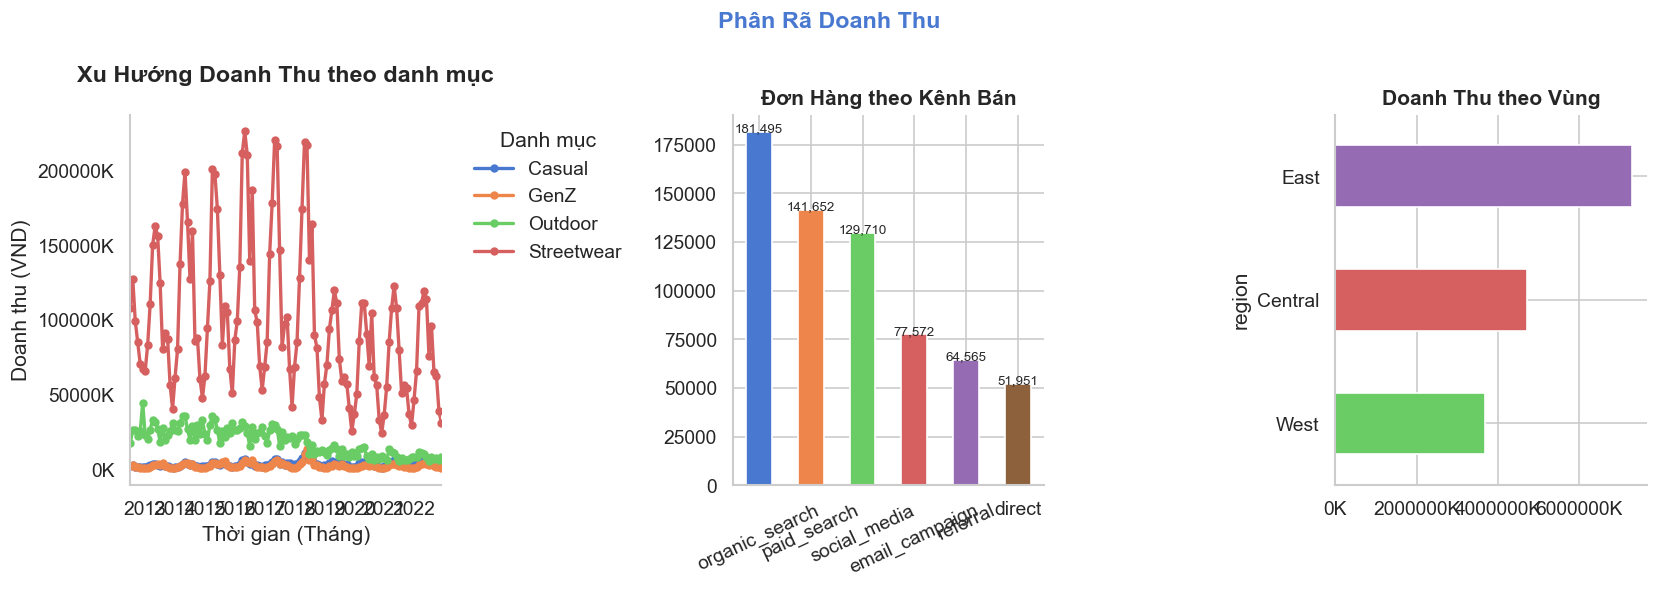

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Revenue by category
df_trend = (
    order_items
    .merge(products[['product_id', 'category']], on='product_id')
    .merge(orders[['order_id', 'order_date']], on='order_id')
)
df_trend['order_date'] = pd.to_datetime(df_trend['order_date'])

cat_trend_data = (
    df_trend
    .groupby([pd.Grouper(key='order_date', freq='ME'), 'category'])['line_rev']
    .sum()
    .unstack()
    .fillna(0)
)
cat_trend_data.plot(kind='line', ax=axes[0], marker='o', markersize=4, linewidth=2)

axes[0].set_title('Xu Hướng Doanh Thu theo danh mục', fontweight='bold', fontsize=14, pad=20)
axes[0].set_xlabel('Thời gian (Tháng)')
axes[0].set_ylabel('Doanh thu (VND)')

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].legend(title='Danh mục', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

axes[0].yaxis.grid(False)
axes[0].xaxis.grid(False)

plt.tight_layout()

src = orders_full['order_source'].value_counts()
src.plot.bar(ax=axes[1], color=PALETTE, rot=25)
axes[1].set_title('Đơn Hàng theo Kênh Bán', fontweight='bold')
axes[1].set_xlabel('')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=8)

#Revenue by region
reg_rev = orders_full.groupby('region')['revenue'].sum().sort_values()
reg_rev.plot.barh(ax=axes[2], color=PALETTE[2:])
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
axes[2].set_title('Doanh Thu theo Vùng', fontweight='bold')

plt.suptitle('Phân Rã Doanh Thu',
             fontsize=14, fontweight='bold', color=PALETTE[0])
plt.tight_layout()
plt.show()

Streetwear áp đảo và là category nổi bật nhất, chi phối doanh thu với xu hướng mùa vụ tương tự. Organic search dẫn đầu; ba kênh đầu chiếm khoảng 68% tổng đơn hàng.

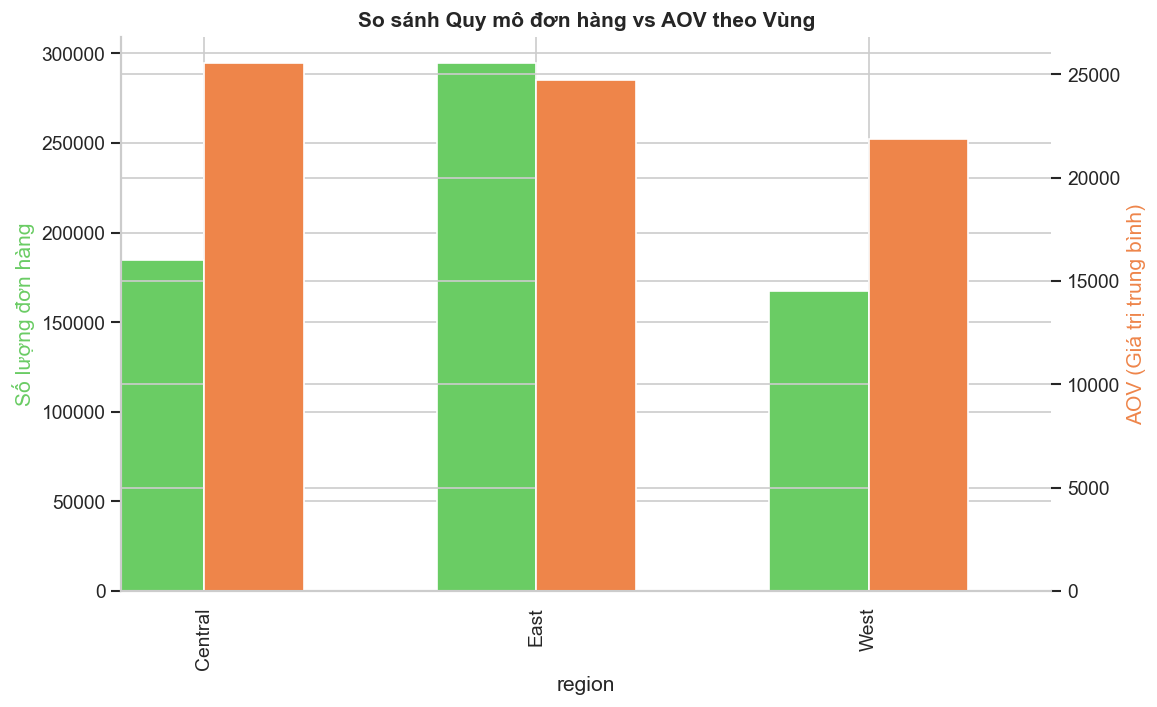

In [17]:
region_stats = (
    orders_full
    .groupby('region')
    .agg(n_orders=('order_id', 'nunique'), 
         revenue=('revenue', 'sum'))
)
region_stats['aov'] = region_stats['revenue'] / region_stats['n_orders']

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

region_stats['n_orders'].plot(kind='bar', ax=ax1, color=PALETTE[2], position=1, width=0.3, label='Số đơn hàng')
region_stats['aov'].plot(kind='bar', ax=ax2, color=PALETTE[1], position=0, width=0.3, label='AOV')

ax1.set_ylabel('Số lượng đơn hàng', color=PALETTE[2])
ax2.set_ylabel('AOV (Giá trị trung bình)', color=PALETTE[1])
plt.title('So sánh Quy mô đơn hàng vs AOV theo Vùng', fontweight='bold')
plt.show()

East là thị trường chủ yếu, có doanh thu cao nhờ cả số lượng đơn và giá trị đơn. Tuy nhiên, Central cũng rất tiềm năng vì có AOV cao nhất.

## 5. Phân Tích Khách Hàng

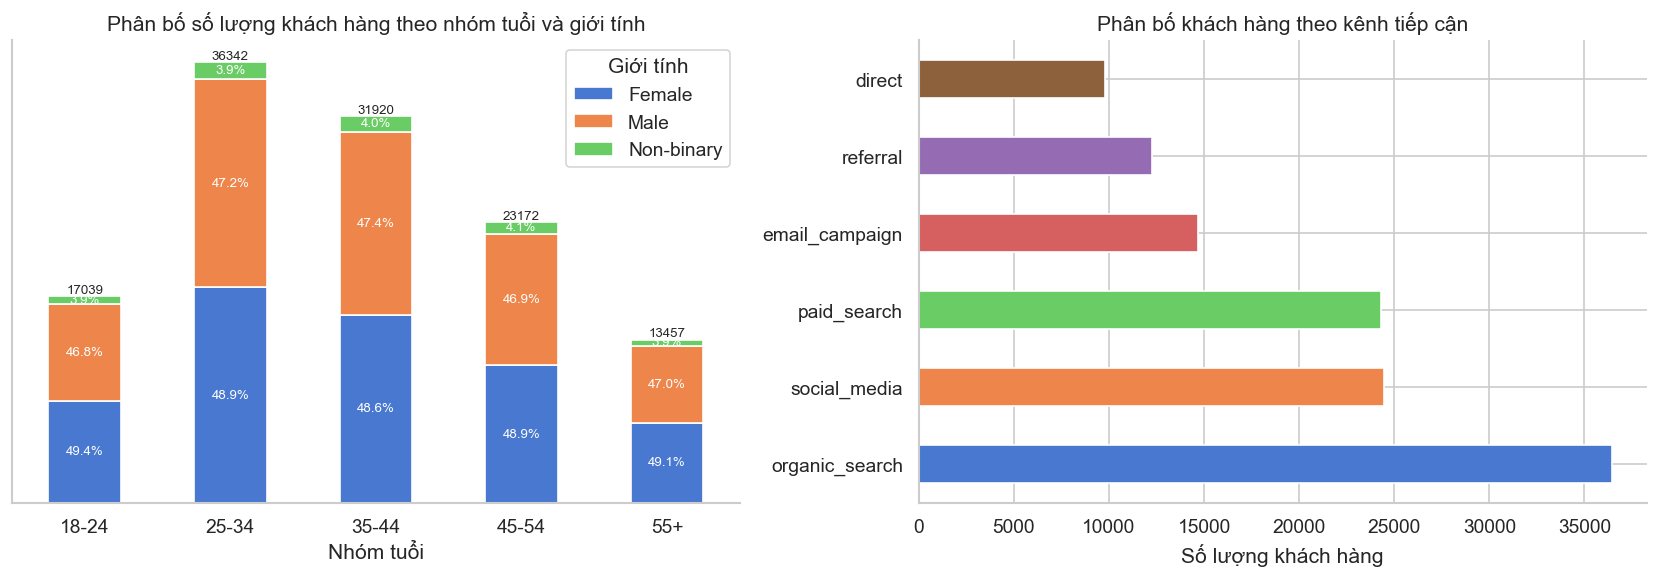

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# nhóm tuổi x giới tính
age_gender_counts = customers.groupby(['age_group','gender']).size().unstack(fill_value=0)
age_order = sorted(customers['age_group'].dropna().unique())
age_gender_counts = age_gender_counts.reindex(age_order)

age_gender_counts.plot(ax=axes[0], kind='bar', stacked=True, rot=0, 
                            color=PALETTE[:age_gender_counts.shape[1]])

axes[0].set_title('Phân bố số lượng khách hàng theo nhóm tuổi và giới tính')
axes[0].set_xlabel('Nhóm tuổi')
axes[0].set_ylabel('Số lượng khách hàng')
axes[0].legend(title='Giới tính')
axes[0].yaxis.grid(False)
axes[0].xaxis.grid(False)
axes[0].yaxis.set_visible(False)

age_gender_pct = age_gender_counts.div(age_gender_counts.sum(axis=1), axis=0)
# Thêm tỷ lệ phần trăm trên cột (tuỳ chọn)
totals = age_gender_counts.sum(axis=1)
for i, total in enumerate(totals):
    axes[0].text(i, total + 1, f'{total}', ha='center', va='bottom', fontsize=8)

for i, row in enumerate(age_gender_pct.values):
    cum = 0
    for j, val in enumerate(row):
        count = age_gender_counts.iloc[i, j]
        if val > 0:
            axes[0].text(i, cum + count/2, f'{val:.1%}',
                    ha='center', va='center', fontsize=8, color='white')
        cum += count

plt.tight_layout()
# Acquisition channel
ch = customers['acquisition_channel'].value_counts()
ch.plot.barh(ax=axes[1], color=PALETTE)
axes[1].set_title('Phân bố khách hàng theo kênh tiếp cận')
axes[1].set_xlabel('Số lượng khách hàng')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


In [19]:
customers_age_pct = (
    customers.groupby('age_group')['customer_id'].nunique()
    / customers['customer_id'].nunique() * 100
).rename('pct')

customers_age_pct = customers_age_pct.to_frame()

customers_age_pct['cumulative_pct'] = customers_age_pct['pct'].cumsum()
customers_age_pct

,pct,cumulative_pct
age_group,,
18-24,13.974412,13.974412
25-34,29.805626,43.780038
35-44,26.178955,69.958993
45-54,19.004347,88.963340
55+,11.036660,100.000000


In [20]:
customers['first_order_date'] = customers.merge(orders[['customer_id', 'order_date']], on='customer_id')['order_date'].groupby(customers['customer_id']).transform('min')
customers['tenure_days'] = (pd.Timestamp('2022-12-31') - 
                            customers['first_order_date'])
customers['tenure_days'] = customers['tenure_days'].dt.days
customers['tenure_days']

0         3811
1         3136
2         2710
3         2078
4         1041
          ... 
121925    3432
121926    3410
121927    3103
121928    1709
121929     663
Name: tenure_days, Length: 121930, dtype: int64

One-time buyers : 24.8%
Repeat buyers   : 75.2%
Median orders/cust: 4.00


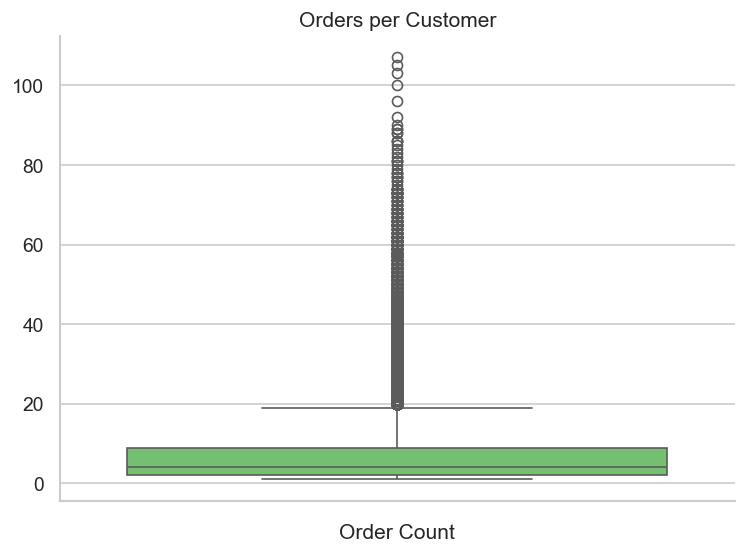

In [21]:

# Orders per customer
opc = orders.groupby('customer_id').size()
sns.boxplot(data=opc, color=PALETTE[2], showfliers=True)
plt.gca().set_title('Orders per Customer')
plt.xlabel('Order Count')

print(f'One-time buyers : {(opc == 1).mean():.1%}')
print(f'Repeat buyers   : {(opc  > 1).mean():.1%}')
print(f'Median orders/cust: {opc.median():.2f}') # do bị ảnh hưởng nhiều bởi các đơn đột biến

plt.tight_layout()
plt.show()

Mô hình mua hàng: tần suất cao, AOV thấp. Có những khách hàng với số đơn hàng rất cao (outliers), kéo chỉ số trung bình lên cao dù số lượng khách hàng này rất ít.

Ngưỡng để trở thành top 5%: >= 24 đơn hàng
Tỷ lệ số lượng khách trong top 5%: 5.5%
Tỷ lệ doanh thu đóng góp: 25.5%


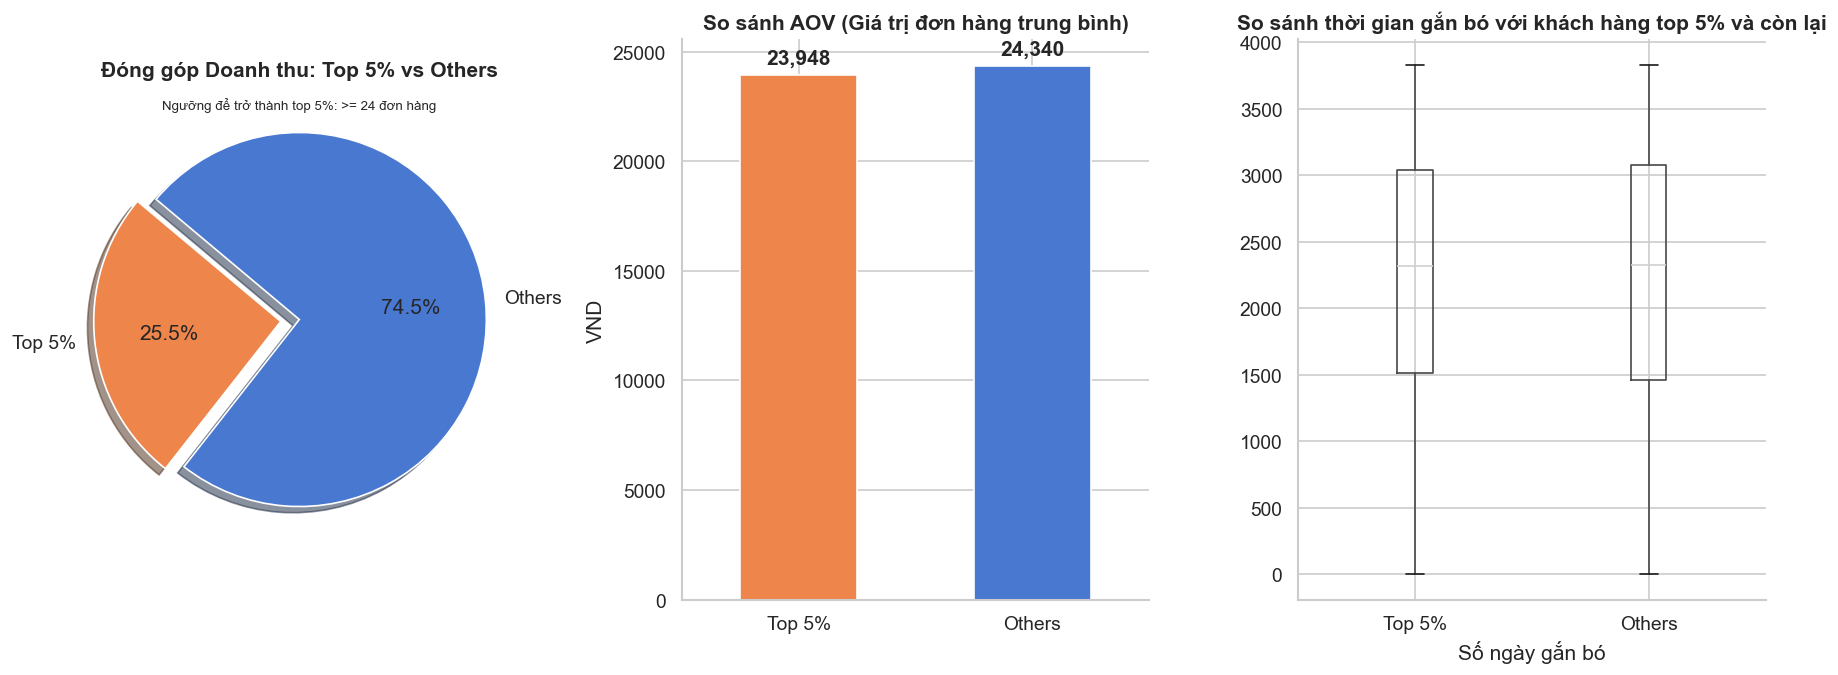

In [26]:
# 1. Tính toán tần suất và doanh thu theo từng khách hàng
cust_summary = (
    order_items.merge(orders[['order_id', 'customer_id']], on='order_id')
    .groupby('customer_id')
    .agg(
        frequency=('order_id', 'nunique'),
        monetary=('line_rev', 'sum')
    )
)
top_threshold = cust_summary['frequency'].quantile(0.95)
cust_summary = cust_summary.merge(customers[['customer_id', 'tenure_days']], on='customer_id')
cust_summary['top_5pct'] = cust_summary['frequency'] >= top_threshold
# Top 5% khách hàng mua nhiều nhất

super_fans = cust_summary[cust_summary['frequency'] >= top_threshold]
others = cust_summary[cust_summary['frequency'] < top_threshold]

# Tính toán tỷ trọng đóng góp
total_rev = cust_summary['monetary'].sum()
sf_rev_share = (super_fans['monetary'].sum() / total_rev) * 100
sf_count_share = (len(super_fans) / len(cust_summary)) * 100

print(f"Ngưỡng để trở thành top 5%: >= {top_threshold:.0f} đơn hàng")
print(f"Tỷ lệ số lượng khách trong top 5%: {sf_count_share:.1f}%")
print(f"Tỷ lệ doanh thu đóng góp: {sf_rev_share:.1f}%")
labels = ['Top 5%', 'Others']
rev_shares = [sf_rev_share, 100 - sf_rev_share]
customer_counts = [len(super_fans), len(others)]

# Tính AOV trung bình của từng nhóm để so sánh chất lượng đơn hàng
sf_aov = super_fans['monetary'].sum() / super_fans['frequency'].sum()
others_aov = others['monetary'].sum() / others['frequency'].sum()


fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Biểu đồ tròn: Tỷ trọng doanh thu
axes[0].pie(rev_shares, labels=labels, autopct='%1.1f%%', startangle=140, 
            colors=[PALETTE[1], PALETTE[0]], explode=(0.1, 0), shadow=True)
axes[0].set_title(f'Đóng góp Doanh thu: Top 5% vs Others', fontweight='bold')
axes[0].text(
    0.5, 0.95,  # vị trí tương đối so với trục (x=giữa, y=trên trục)
    f"Ngưỡng để trở thành top 5%: >= {top_threshold:.0f} đơn hàng",
    transform=axes[0].transAxes,
    fontsize=8,
    ha='center'
)
# Biểu đồ cột: So sánh AOV
aov_comparison = pd.Series([sf_aov, others_aov], index=labels)
aov_comparison.plot(kind='bar', ax=axes[1], color=[PALETTE[1], PALETTE[0]])
axes[1].set_title('So sánh AOV (Giá trị đơn hàng trung bình)', fontweight='bold')
axes[1].set_ylabel('VND')
axes[1].set_xticklabels(labels, rotation=0)

# Thêm số liệu trực tiếp trên đầu cột AOV
for i, v in enumerate([sf_aov, others_aov]):
    axes[1].text(i, v + 500, f'{v:,.0f}', ha='center', fontweight='bold')


plt.tight_layout()

# So sánh số ngày gắn bó với khách hàng top 5% và còn lại
cust_summary.boxplot(ax=axes[2], column='tenure_days', by='top_5pct')
axes[2].set_title('So sánh thời gian gắn bó với khách hàng top 5% và còn lại', fontweight='bold')
axes[2].set_xlabel('Số ngày gắn bó')
axes[2].set_xticklabels(labels, rotation=0)
plt.suptitle('')
plt.tight_layout()

plt.show()

Chỉ hơn 5% khách hàng đóng góp tới gần 26% doanh thu. Tuy nhiên AOV không có sự khác biệt quá lớn -> doanh thu đóng góp được lớn nhờ số lượng mua hàng lớn.

### So Sánh Phân Khúc: Khách Hàng Mới vs. Quay Lại

In [27]:
seg_monthly_count = (
    orders_seg
    .set_index('order_date')
    .groupby([pd.Grouper(freq='ME'), 'segment'])['customer_id']
    .count()
    .unstack('segment')
    .fillna(0)
)
seg_monthly_count

segment,Khách mới,Khách quay lại
order_date,,
2012-07-31,4921,373
2012-08-31,5176,1251
2012-09-30,3641,1578
2012-10-31,2653,1632
2012-11-30,2298,1844
...,...,...
2022-08-31,132,3142
2022-09-30,93,2550
2022-10-31,52,2045


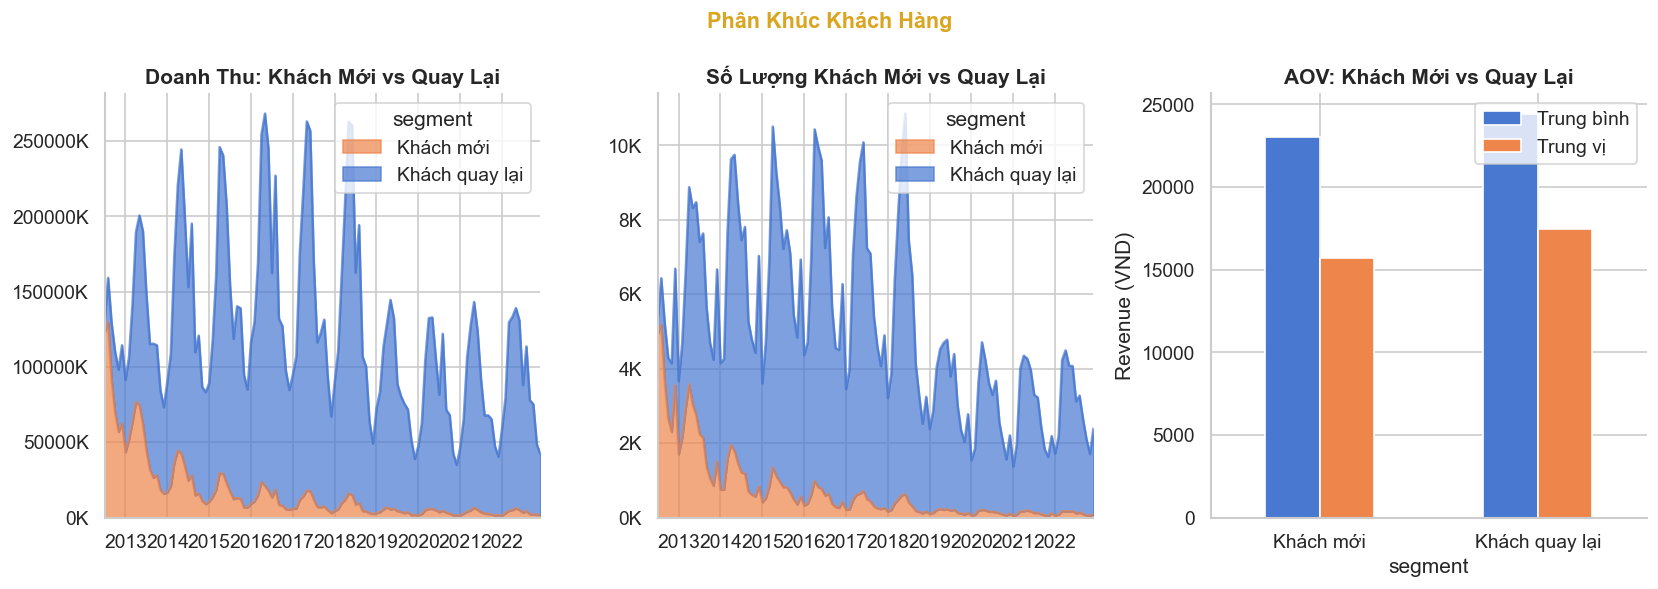

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Stacked area
seg_monthly.plot.area(ax=axes[0], alpha=0.7, color=[PALETTE[1], PALETTE[0]])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
axes[0].set_title('Doanh Thu: Khách Mới vs Quay Lại', fontweight='bold')
axes[0].set_xlabel('')

seg_monthly_count.plot.area(ax=axes[1], alpha=0.7, color=[PALETTE[1], PALETTE[0]])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
axes[1].set_title('Số Lượng Khách Mới vs Quay Lại', fontweight='bold')
axes[1].set_xlabel('')

# AOV comparison
seg_aov = orders_seg.groupby('segment')['revenue'].agg(['mean','median'])
seg_aov[['mean','median']].plot.bar(ax=axes[2], color=[PALETTE[0], PALETTE[1]], rot=0)
axes[2].set_title('AOV: Khách Mới vs Quay Lại', fontweight='bold')
axes[2].set_ylabel('Revenue (VND)')
axes[2].legend(['Trung bình','Trung vị'])

plt.suptitle('Phân Khúc Khách Hàng',
             fontsize=13, fontweight='bold', color='goldenrod')
plt.tight_layout()
plt.show()

## 6. Tỷ Lệ Hoàn Trả & Đánh Giá Sản Phẩm

In [29]:
products['product_line'] = (
    products['product_name']
    .str.replace(r'\s+\S+$', '', regex=True)  
    .str.strip()
)

print(f'\nSố product lines: {products["product_line"].nunique()}')
print(f'Số products     : {products["product_name"].nunique()}')


Số product lines: 14
Số products     : 2172


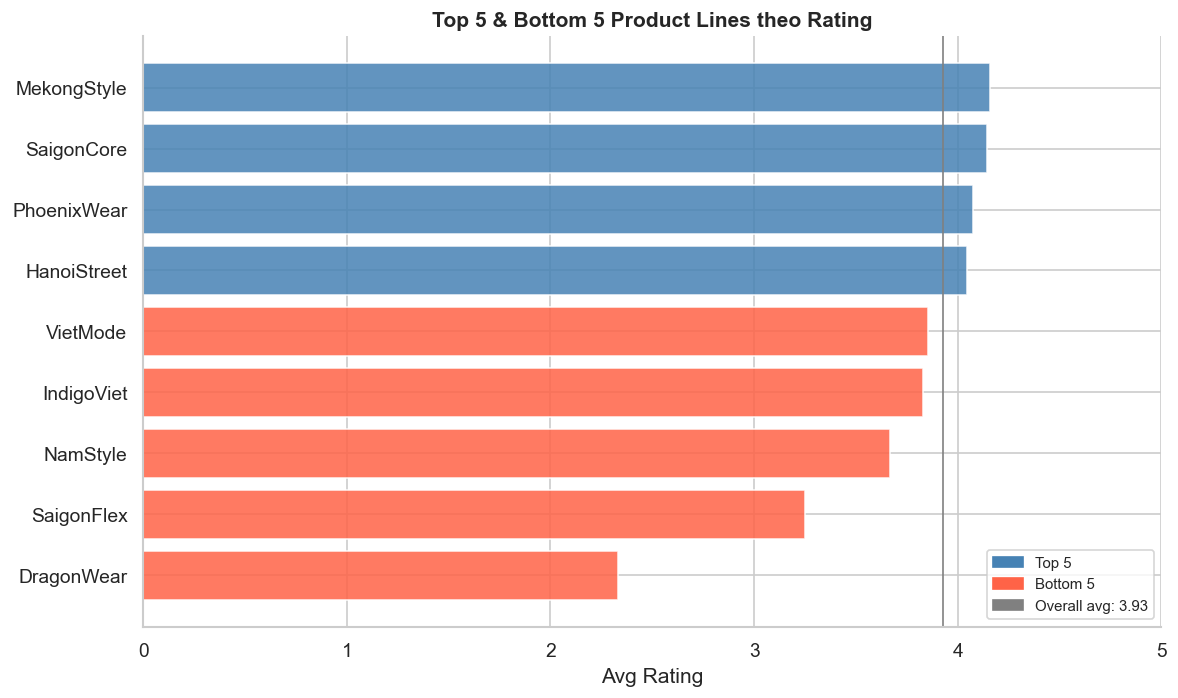

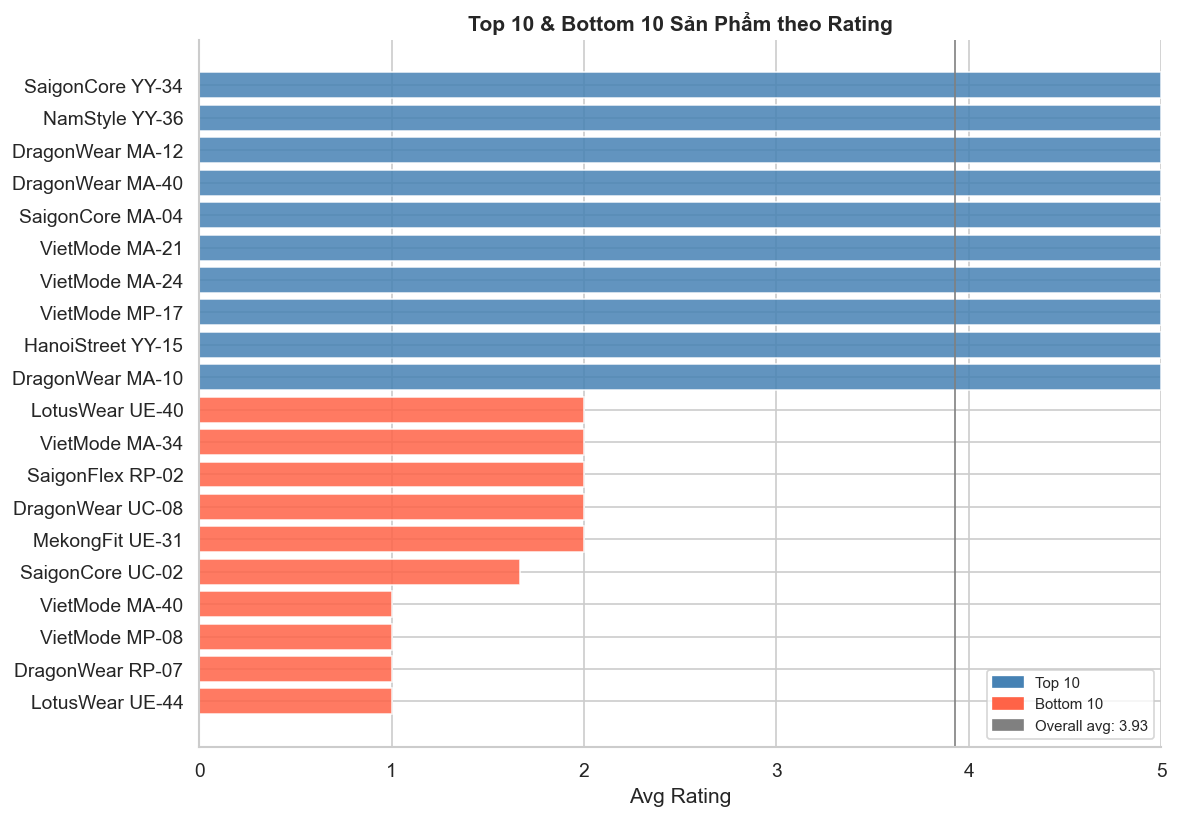

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# - Aggregate by product_line -
prod_ratings_line = (
    reviews
    .merge(products[['product_id', 'product_line', 'category']], on='product_id')
    .groupby(['category', 'product_line'])
    .agg(
        avg_rating = ('rating', 'mean'),
        n_reviews  = ('rating', 'count'),
        pct_5star  = ('rating', lambda x: (x == 5).mean()),
        pct_1star  = ('rating', lambda x: (x == 1).mean()),
    )
    .reset_index()
)

# - Aggregate by product_name -
prod_ratings_name = (
    reviews
    .merge(products[['product_id', 'product_name', 'category']], on='product_id')
    .groupby(['category', 'product_name'])
    .agg(
        avg_rating = ('rating', 'mean'),
        n_reviews  = ('rating', 'count'),
        pct_5star  = ('rating', lambda x: (x == 5).mean()),
        pct_1star  = ('rating', lambda x: (x == 1).mean()),
    )
    .reset_index()
)

overall_avg = prod_ratings_name['avg_rating'].mean()

def make_top_bottom_chart(ax, df, label_col, n, title):
    """Reusable top/bottom bar chart."""
    top = df.nlargest(n, 'avg_rating')
    bot = df.nsmallest(n, 'avg_rating')
    combined = pd.concat([top, bot]).drop_duplicates(label_col).sort_values('avg_rating')
    colors = combined[label_col].isin(top[label_col]).map(
        {True: 'steelblue', False: 'tomato'}
    )
    ax.barh(combined[label_col], combined['avg_rating'],
            color=colors, alpha=0.85)
    ax.axvline(overall_avg, color='gray', linestyle='-', linewidth=1)
    ax.set_xlim(0, 5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Avg Rating')
    ax.legend(handles=[
        mpatches.Patch(color='steelblue', label=f'Top {n}'),
        mpatches.Patch(color='tomato',    label=f'Bottom {n}'),
        mpatches.Patch(color='gray',      label=f'Overall avg: {overall_avg:.2f}'),
    ], fontsize=9)

# - Figure 1: by product_line -
fig1, ax1 = plt.subplots(figsize=(10, 6))
make_top_bottom_chart(ax1, prod_ratings_line, 'product_line', 5,
                      'Top 5 & Bottom 5 Product Lines theo Rating')
plt.tight_layout()
plt.show()

# - Figure 2: by product_name -
fig2, ax2 = plt.subplots(figsize=(10, 7))
make_top_bottom_chart(ax2, prod_ratings_name, 'product_name', 10,
                      'Top 10 & Bottom 10 Sản Phẩm theo Rating')
plt.tight_layout()
plt.show()

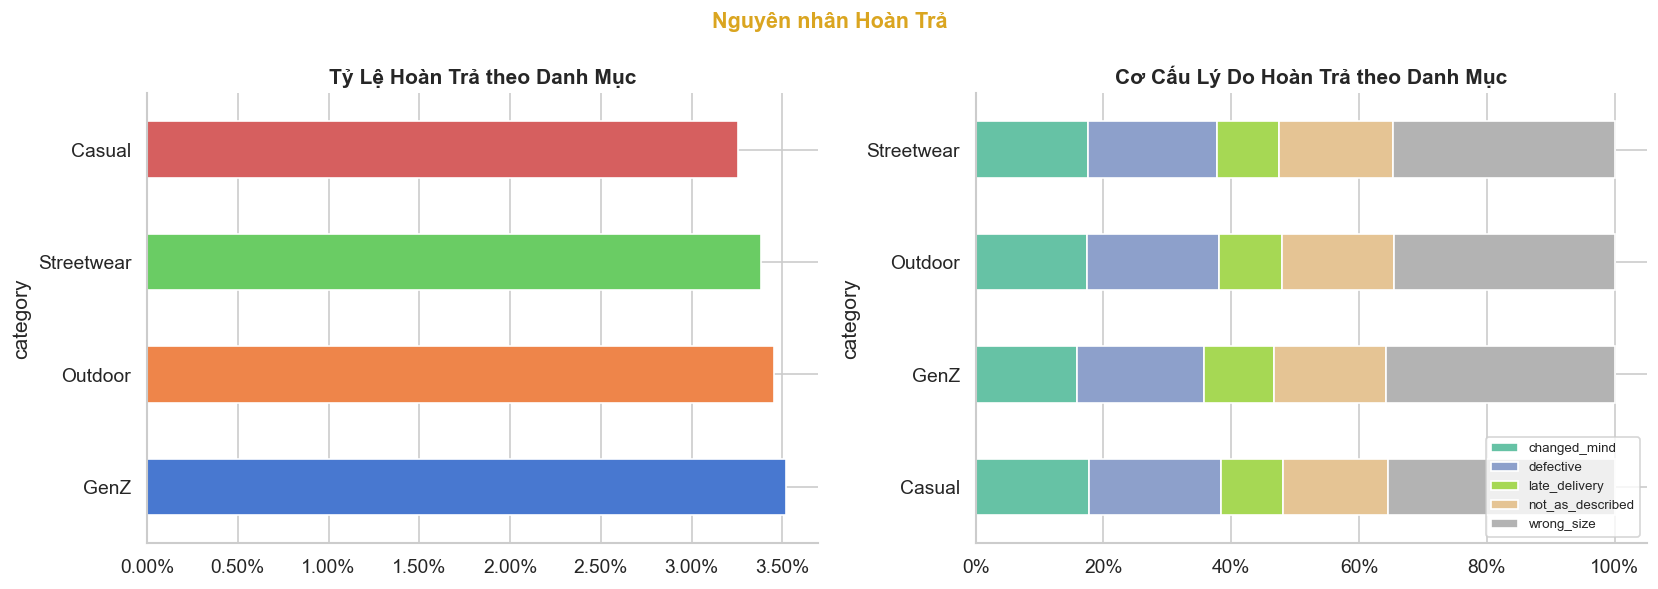

In [31]:
ret_enriched = (
    returns
    .merge(products[['product_id','category']], on='product_id')
    .merge(order_items[['order_id','product_id','quantity']],
           on=['order_id','product_id'], how='left')
)
sold_by_cat = (
    order_items
    .merge(products[['product_id','category']], on='product_id')
    .groupby('category')['quantity'].sum()
)
ret_by_cat = ret_enriched.groupby('category')['return_quantity'].sum()
ret_rate_cat = (ret_by_cat / sold_by_cat).sort_values(ascending=False)

reason_cat = (
    ret_enriched
    .groupby(['category','return_reason'])['return_quantity'].sum()
    .unstack('return_reason').fillna(0)
)
reason_cat_pct = reason_cat.div(reason_cat.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ret_rate_cat.plot.barh(ax=axes[0], color=PALETTE)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[0].set_title('Tỷ Lệ Hoàn Trả theo Danh Mục', fontweight='bold')

reason_cat_pct.plot.barh(stacked=True, ax=axes[1],
                         colormap='Set2')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].set_title('Cơ Cấu Lý Do Hoàn Trả theo Danh Mục', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)

plt.suptitle('Nguyên nhân Hoàn Trả',
             fontsize=13, fontweight='bold', color='goldenrod')
plt.tight_layout()
plt.show()

Nhìn chung, tỷ lệ hoàn hàng giữa các danh mục không có sự khác biệt rõ rệt. Lý do hoàn hàng chủ yếu liên quan đến đặc tính sản phẩm (sai kích cỡ, lỗi,...) hơn là vấn đề giao hàng.

## 7. Phân Tích Sản Phẩm & Danh Mục

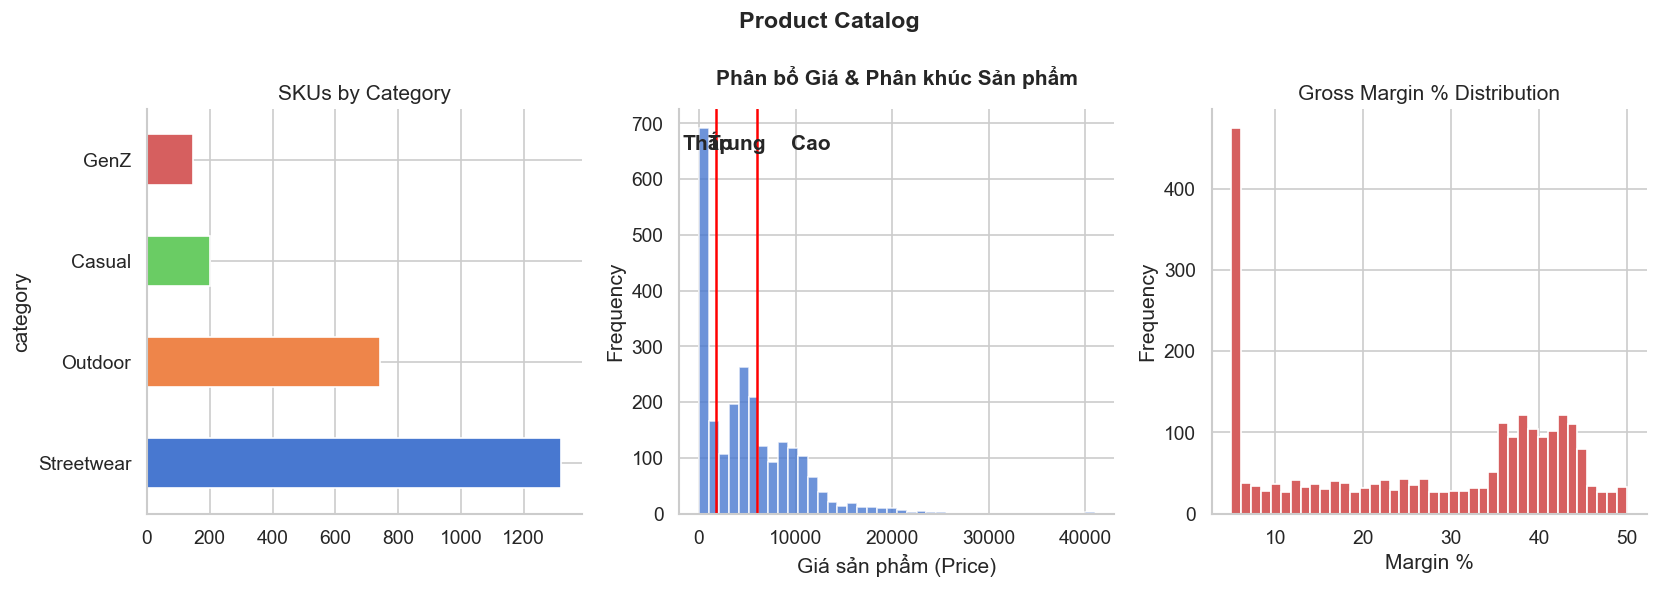

          price      cogs  margin_pct
count   2412.00   2412.00     2412.00
mean    4928.22   3868.35       26.59
std     4776.74   3878.58       15.11
min        9.06      5.18        5.00
25%       59.44     35.07       10.40
50%     4399.60   3184.93       30.58
75%     7720.51   5864.92       40.12
max    40950.00  38902.50       49.96


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Category breakdown
products['category'].value_counts().plot.barh(ax=axes[0], color=PALETTE)
axes[0].set_title('SKUs by Category')

# Price distribution
# 1. Tìm các mốc phân chia (cắt ở 33.3% và 66.7% dữ liệu)
p33 = products['price'].quantile(0.333)
p67 = products['price'].quantile(0.667)

# 2. Gán nhãn phân khúc trực tiếp vào Dataframe để tiện phân tích sau này
products['price_segment'] = pd.cut(
    products['price'], 
    bins=[0, p33, p67, float('inf')], 
    labels=['Thấp', 'Trung', 'Cao']
)

# 3. Vẽ biểu đồ Histogram (như cũ)
products['price'].plot.hist(bins=40, ax=axes[1], color=PALETTE[0], edgecolor='white', alpha=0.8)

# 4. Thêm đường cắt và Text chia vùng trên biểu đồ
axes[1].axvline(p33, color='red', linestyle='-', linewidth=1.5)
axes[1].axvline(p67, color='red', linestyle='-', linewidth=1.5)

# Tự động lấy chiều cao của biểu đồ để căn chỉnh chữ
y_max = axes[1].get_ylim()[1]
axes[1].text(p33 * 0.5, y_max * 0.9, f'Thấp', ha='center', fontweight='bold')
axes[1].text((p33 + p67) * 0.5, y_max * 0.9, f'Trung', ha='center', fontweight='bold')
axes[1].text(p67 + (products['price'].max()-p67)*0.1, y_max * 0.9, f'Cao', ha='left', fontweight='bold')

axes[1].set_title('Phân bổ Giá & Phân khúc Sản phẩm', fontweight='bold', pad=15)
axes[1].set_xlabel('Giá sản phẩm (Price)')

# Gross-margin proxy
products['margin_pct'] = (products['price'] - products['cogs']) / products['price'] * 100
products['margin_pct'].plot.hist(bins=40, ax=axes[2], color=PALETTE[3], edgecolor='white')
axes[2].set_title('Gross Margin % Distribution')
axes[2].set_xlabel('Margin %')

plt.suptitle('Product Catalog', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(products[['price','cogs','margin_pct']].describe().round(2))

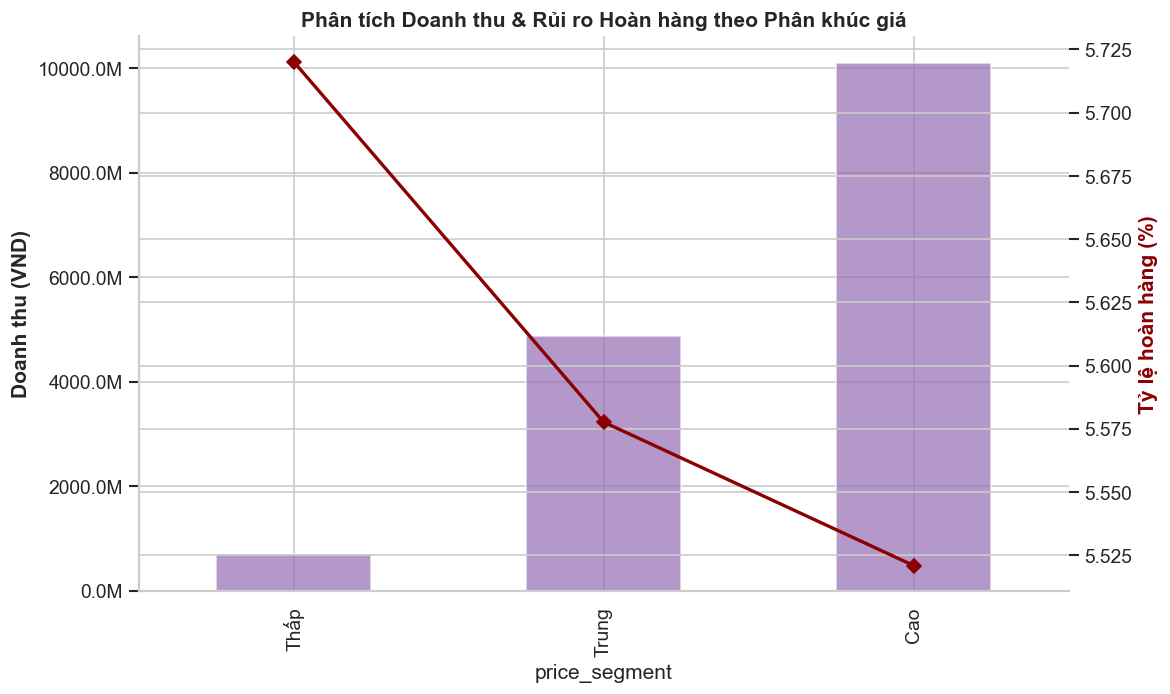

In [33]:

returned_items = returns[['order_id', 'product_id']].drop_duplicates()
returned_items['is_returned'] = 1

# 2. Merge vào bảng order_items chính
df_analysis = (
    order_items
    .merge(products[['product_id', 'price', 'price_segment']], on='product_id')
    .merge(returned_items, on=['order_id', 'product_id'], how='left')
)

# Điền 0 cho những sản phẩm không nằm trong bảng returns
df_analysis['is_returned'] = df_analysis['is_returned'].fillna(0)

# 3. Tổng hợp dữ liệu theo Phân khúc
segment_stats = df_analysis.groupby('price_segment').agg(
    total_revenue=('line_rev', 'sum'),
    total_items=('order_id', 'count'),
    return_count=('is_returned', 'sum')
)

segment_stats['return_rate'] = (segment_stats['return_count'] / segment_stats['total_items']) * 100

# 4. Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Doanh thu (Cột)
segment_stats['total_revenue'].plot(kind='bar', ax=ax1, color=PALETTE[4], alpha=0.7)
# Tỷ lệ hoàn hàng (Đường)
segment_stats['return_rate'].plot(kind='line', ax=ax2, color='darkred', marker='D', linewidth=2)

ax1.set_ylabel('Doanh thu (VND)', fontweight='bold')
ax2.set_ylabel('Tỷ lệ hoàn hàng (%)', color='darkred', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title('Phân tích Doanh thu & Rủi ro Hoàn hàng theo Phân khúc giá', fontweight='bold')
plt.show()

Phân khúc sản phẩm giá cao có tỷ lệ hoàn hàng thấp hơn.

<Axes: xlabel='price', ylabel='return_rate'>

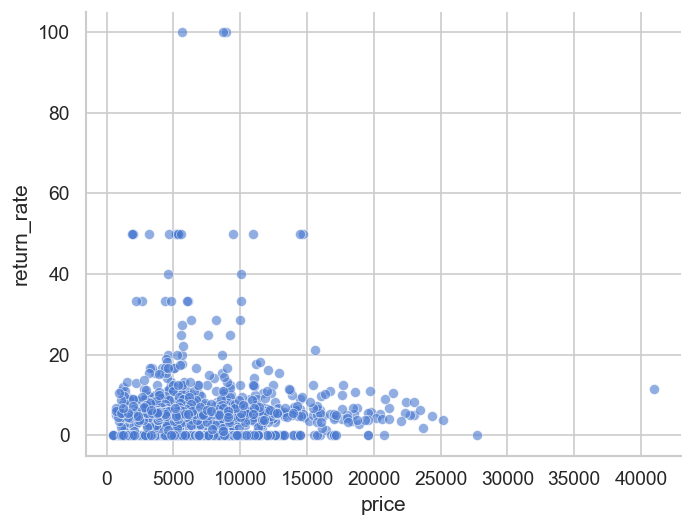

In [34]:
price_vs_return = df_analysis.groupby('product_id').agg(
    total_revenue=('line_rev', 'sum'),
    total_items=('order_id', 'count'),
    return_count=('is_returned', 'sum'),
    price = ('price', 'mean')
)

price_vs_return['return_rate'] = (price_vs_return['return_count'] / price_vs_return['total_items']) * 100

sns.scatterplot(x='price', y='return_rate', data=price_vs_return,
                palette=PALETTE, alpha=0.6, edgecolor='white')

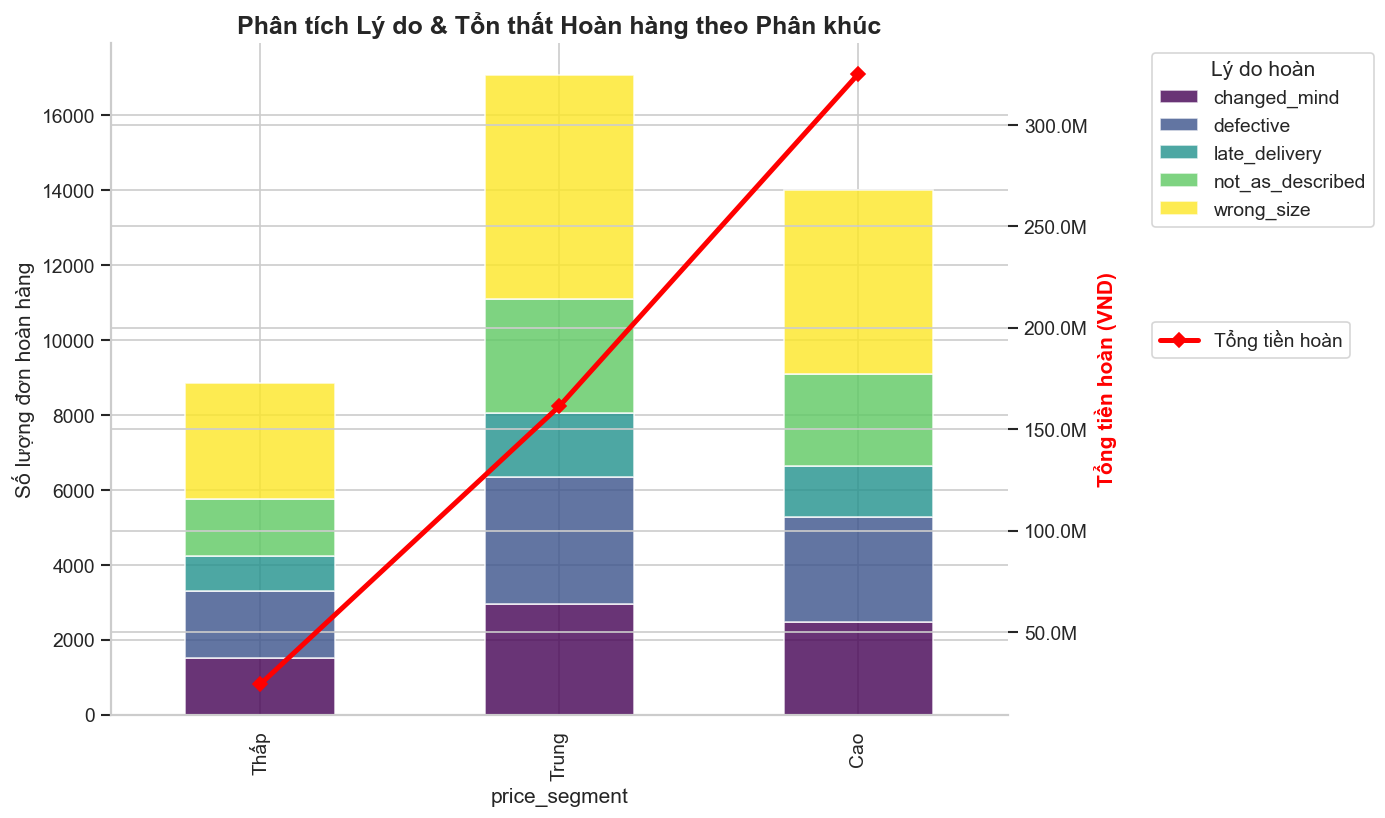

In [35]:
# 1. Tổng hợp dữ liệu chi tiết từ bảng returns
# Kết nối returns -> order_items (lấy segment) -> products
returns_detail = (
    returns.merge(order_items[['order_id', 'product_id', 'line_rev']], on=['order_id', 'product_id'])
    .merge(products[['product_id', 'price_segment']], on='product_id')
)

# 2. Tạo bảng pivot: Lý do hoàn theo phân khúc (tính theo số lượng đơn)
reason_pivot = returns_detail.pivot_table(
    index='price_segment', 
    columns='return_reason', 
    values='return_id', 
    aggfunc='count'
).reindex(['Thấp', 'Trung', 'Cao'])

# 3. Tính tổng tiền hoàn theo phân khúc
money_stats = returns_detail.groupby('price_segment')['refund_amount'].sum().reindex(['Thấp', 'Trung', 'Cao'])

# 4. Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

# Vẽ cột chồng (Lý do hoàn hàng)
reason_pivot.plot(kind='bar', stacked=True, ax=ax1, alpha=0.8, colormap='viridis')

# Vẽ đường tổng tiền hoàn (Refund Amount)
money_stats.plot(kind='line', ax=ax2, color='red', marker='D', linewidth=3, label='Tổng tiền hoàn')

# Tinh chỉnh giao diện
ax1.set_title('Phân tích Lý do & Tổn thất Hoàn hàng theo Phân khúc', fontweight='bold', fontsize=15)
ax1.set_ylabel('Số lượng đơn hoàn hàng')
ax2.set_ylabel('Tổng tiền hoàn (VND)', color='red', fontweight='bold')

# Định dạng tiền tệ cho trục phụ
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Đưa chú thích ra ngoài
ax1.legend(title='Lý do hoàn', bbox_to_anchor=(1.15, 1), loc='upper left')
ax2.legend(loc='upper left', bbox_to_anchor=(1.15, 0.6))

plt.tight_layout()
plt.show()

Tổng số sản phẩm hoàn về ở tầm giá trung là nhiều nhất. Tỷ lệ lý do hoàn ở các phân khúc không có sự khác biệt đáng kể.

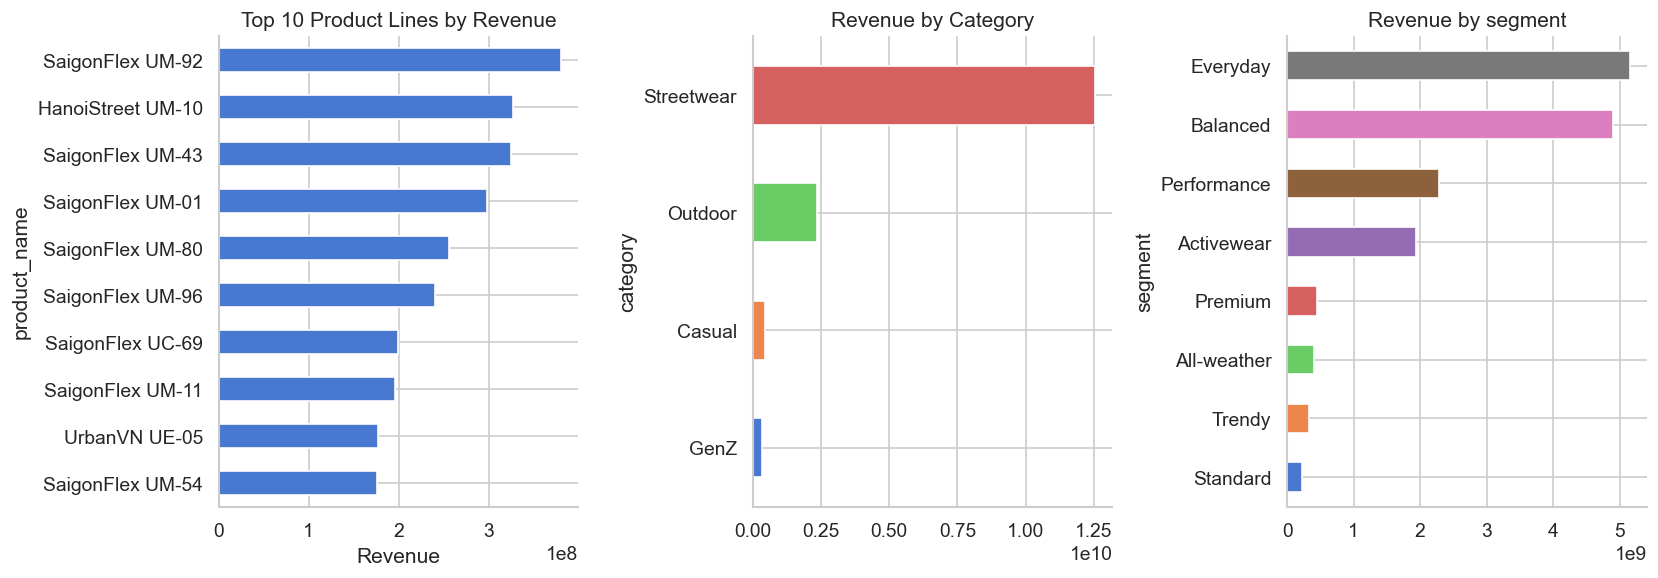

In [36]:
# Top products by revenue
item_rev = (
    order_items
    .assign(revenue=lambda x: x['unit_price'] * x['quantity'] - x['discount_amount'])
    .groupby('product_id')['revenue'].sum()
    .reset_index()
    .merge(products[['product_id','product_name',  'category', 'segment']], on='product_id')
    .sort_values('revenue', ascending=False)
)
top_line = (
    item_rev
    .groupby('product_name')['revenue'].sum()
    .reset_index()
    .sort_values('revenue', ascending=False)
)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

top_line.head(10).set_index('product_name')['revenue'].plot.barh(
    ax=axes[0], color=PALETTE[0])
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Product Lines by Revenue')
axes[0].set_xlabel('Revenue')

# Revenue share by category
item_rev.groupby('category')['revenue'].sum().sort_values().plot.barh(
    ax=axes[1], color=PALETTE)
axes[1].set_title('Revenue by Category')

item_rev.groupby('segment')['revenue'].sum().sort_values().plot.barh(
    ax=axes[2], color=PALETTE)
axes[2].set_title('Revenue by segment')

plt.tight_layout()
plt.show()

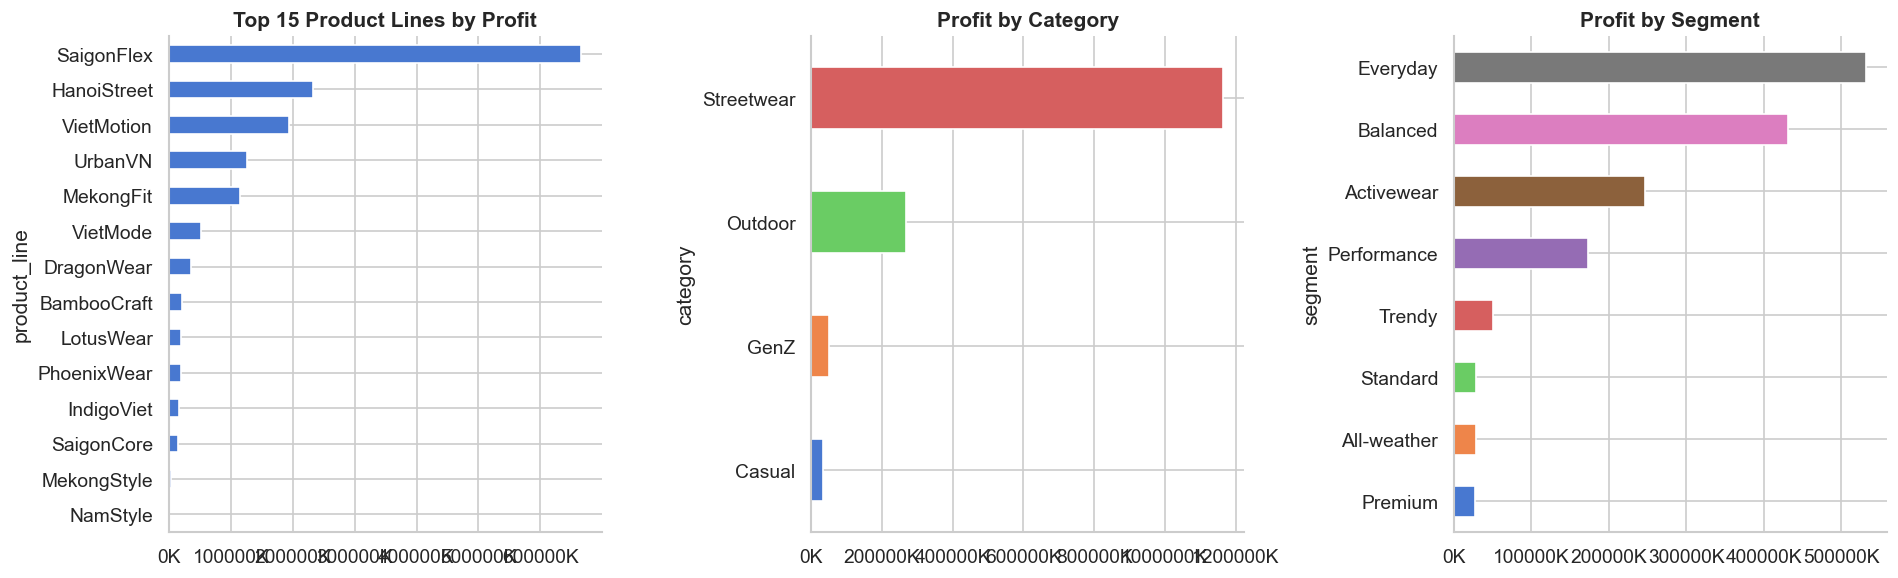

In [37]:
# 1. Tính toán Lợi nhuận (Profit) bằng cách merge order_items với products (lấy COGS)
item_profit = (
    order_items
    .merge(products[['product_id', 'product_name', 'product_line', 'category', 'segment', 'cogs']], on='product_id')
    .assign(
        revenue=lambda x: (x['unit_price'] * x['quantity']) - x['discount_amount'],
        total_cost=lambda x: x['cogs'] * x['quantity'],
        profit=lambda x: x['revenue'] - x['total_cost']
    )
    .groupby(['product_id', 'product_name', 'product_line', 'category', 'segment'])['profit'].sum()
    .reset_index()
    .sort_values('profit', ascending=False)
)

# 2. Groupby theo các chiều phân tích
line_profit = item_profit.groupby('product_line')['profit'].sum().sort_values(ascending=False)
cat_profit = item_profit.groupby('category')['profit'].sum().sort_values()
seg_profit = item_profit.groupby('segment')['profit'].sum().sort_values()

# 3. Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Lợi nhuận theo Line
line_profit.head(15).plot.barh(ax=axes[0], color=PALETTE[0])
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Product Lines by Profit', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Chart 2: Lợi nhuận theo Category
cat_profit.plot.barh(ax=axes[1], color=PALETTE)
axes[1].set_title('Profit by Category', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Chart 3: Lợi nhuận theo Segment
seg_profit.plot.barh(ax=axes[2], color=PALETTE)
axes[2].set_title('Profit by Segment', fontweight='bold')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

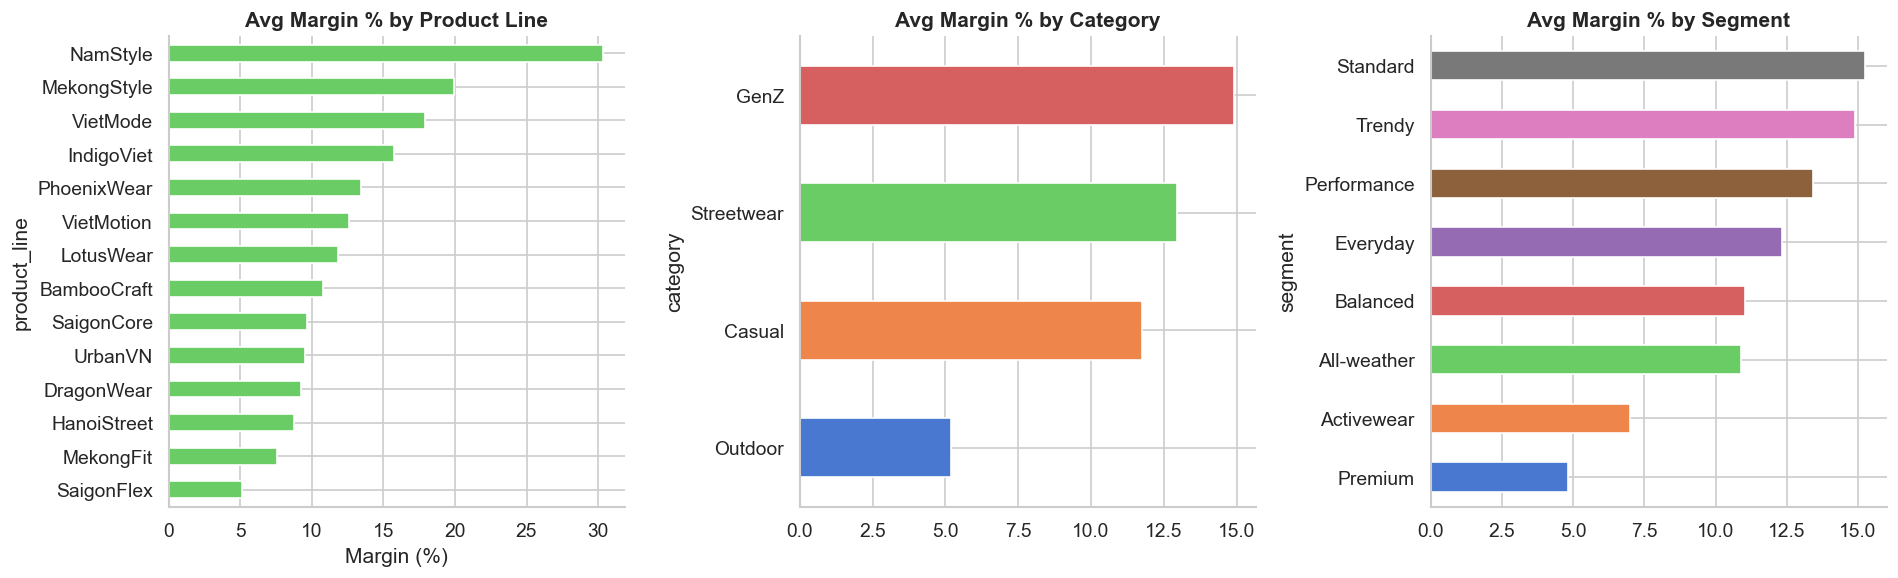

In [38]:
# 1. Tính toán lợi nhuận và biên lợi nhuận (%)
item_analysis = (
    order_items
    .merge(products[['product_id', 'product_name', 'product_line', 'category', 'segment', 'cogs']], on='product_id')
    .assign(
        revenue=lambda x: (x['unit_price'] * x['quantity']) - x['discount_amount'],
        total_cost=lambda x: x['cogs'] * x['quantity'],
        profit=lambda x: x['revenue'] - x['total_cost']
    )
    .groupby(['product_line', 'category', 'segment'])
    .agg(
        total_rev=('revenue', 'sum'),
        total_profit=('profit', 'sum')
    )
    .assign(margin_pct=lambda x: (x['total_profit'] / x['total_rev']) * 100)
    .reset_index()
)

# 2. Vẽ biểu đồ so sánh biên lợi nhuận (%)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Margin by Product Line (Top 15)
item_analysis.groupby('product_line')['margin_pct'].mean().sort_values(ascending=False).head(15).plot.barh(
    ax=axes[0], color=PALETTE[2])
axes[0].invert_yaxis()
axes[0].set_title('Avg Margin % by Product Line', fontweight='bold')
axes[0].set_xlabel('Margin (%)')

# Chart 2: Margin by Category
item_analysis.groupby('category')['margin_pct'].mean().sort_values().plot.barh(
    ax=axes[1], color=PALETTE)
axes[1].set_title('Avg Margin % by Category', fontweight='bold')

# Chart 3: Margin by Segment
item_analysis.groupby('segment')['margin_pct'].mean().sort_values().plot.barh(
    ax=axes[2], color=PALETTE)
axes[2].set_title('Avg Margin % by Segment', fontweight='bold')

plt.tight_layout()
plt.show()

Các hạng mục dẫn đầu gần như không thay đổi thứ tự giữa tổng doanh thu và lợi nhuận. SaigonFlex và HanoiStreet là hai dòng sản phẩm mang về nhiều doanh thu nhất. Tuy nhiên, khi nhìn vào biên lợi nhuận (Margin %), hai dòng này lại nằm ở nhóm cuối. NamStyle và MekongStyle có biên lợi nhuận rất cao (20-30%) nhưng đóng góp tổng lợi nhuận còn khiêm tốn.

## 8. Thanh Toán & Vận Chuyển

Median delivery days : 4
Orders not shipped   : 80,878


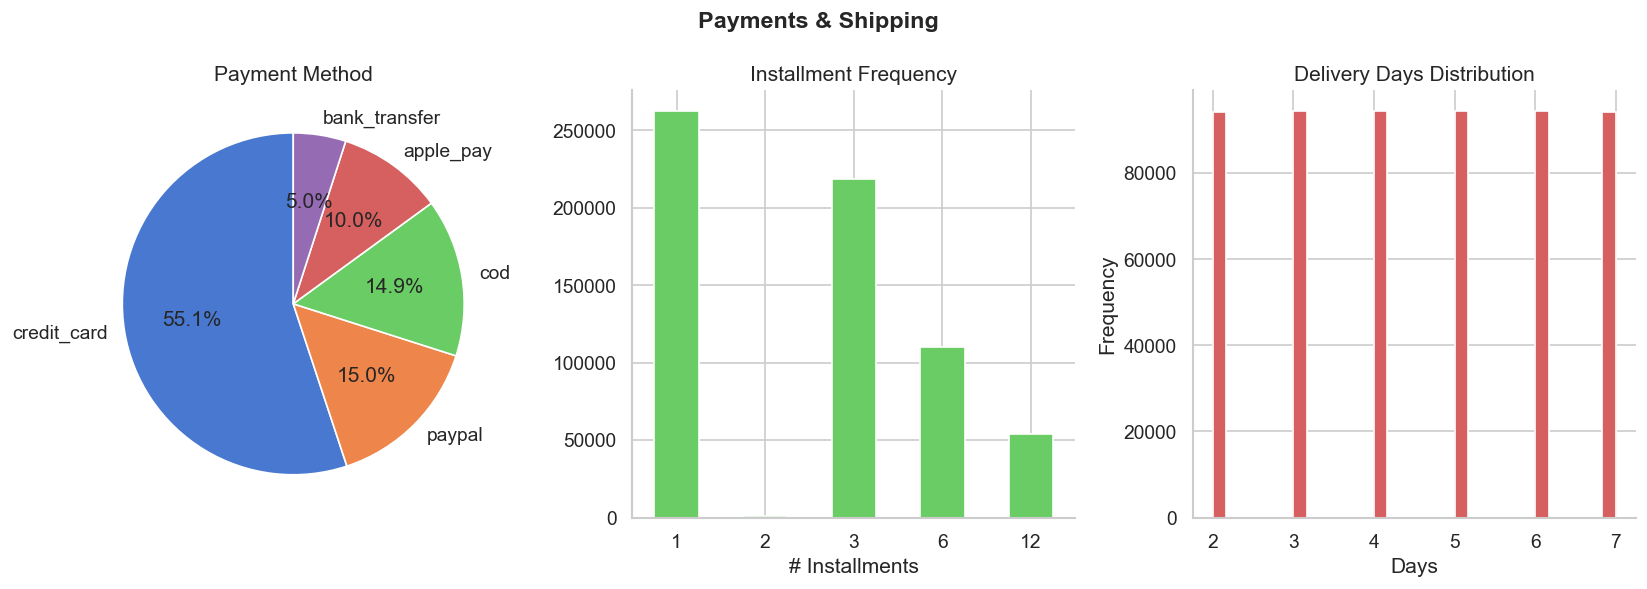

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Payment method split
payments['payment_method'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.1f%%', startangle=90, colors=PALETTE)
axes[0].set_ylabel('')
axes[0].set_title('Payment Method')

# Installments distribution
payments['installments'].value_counts().sort_index().plot.bar(
    ax=axes[1], color=PALETTE[2], rot=0)
axes[1].set_title('Installment Frequency')
axes[1].set_xlabel('# Installments')

# Delivery time
shipments['delivery_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days
shipments['delivery_days'].clip(lower=0, upper=30).plot.hist(
    bins=30, ax=axes[2], color=PALETTE[3], edgecolor='white')
axes[2].set_title('Delivery Days Distribution')
axes[2].set_xlabel('Days')

print(f"Median delivery days : {shipments['delivery_days'].median():.0f}")
print(f"Orders not shipped   : {orders.shape[0] - shipments.shape[0]:,}")

plt.suptitle('Payments & Shipping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Thanh toán không tiền mặt chiếm ưu thế, đặc biệt là thẻ tín dụng. Thanh toán 1 lần là phổ biến nhất; khách hàng có xu hướng chia nhỏ các khoản thanh toán theo quý hoặc nửa năm.

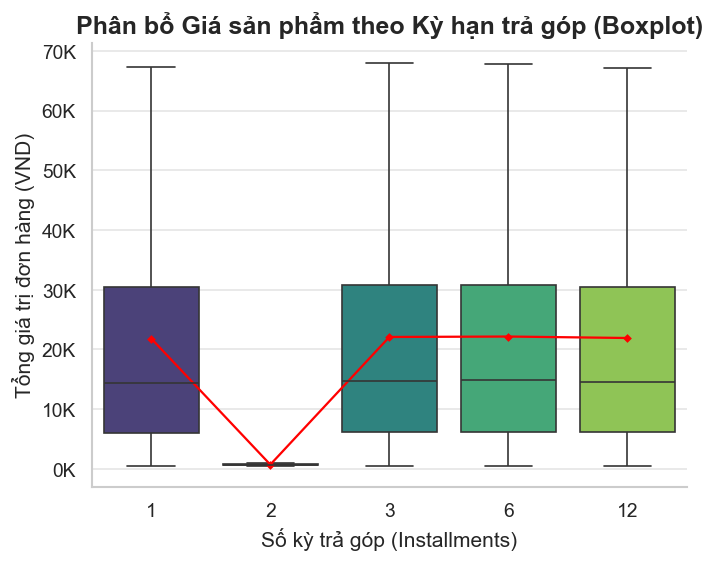

In [40]:
df_box = payments.merge(order_items[['order_id', 'line_rev']], on='order_id')
# showfliers=False để ẩn các điểm ngoại lai quá xa, giúp biểu đồ dễ nhìn hơn
# Bạn có thể đặt lại là True nếu muốn soi các đơn hàng "khủng"
sns.boxplot(data=df_box, x='installments', y='line_rev', 
            palette='viridis', showfliers=False)

# 3. Thêm điểm Mean (Trung bình) bằng hình kim cương đỏ để so sánh với Median
sns.pointplot(data=df_box, x='installments', y='line_rev', 
              color='red', markers='D', scale=0.5, errorbar=None)

# 4. Tinh chỉnh giao diện
plt.title('Phân bổ Giá sản phẩm theo Kỳ hạn trả góp (Boxplot)', fontweight='bold', fontsize=15)
plt.xlabel('Số kỳ trả góp (Installments)')
plt.ylabel('Tổng giá trị đơn hàng (VND)')

# Định dạng trục Y sang đơn vị nghìn (K)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.grid(axis='y', linestyle='-', alpha=0.5)
plt.show()

Không có sự khác biệt đáng kể giữa giá trị đơn hàng với các kỳ trả góp khác nhau.

## 9. Lưu Lượng Web

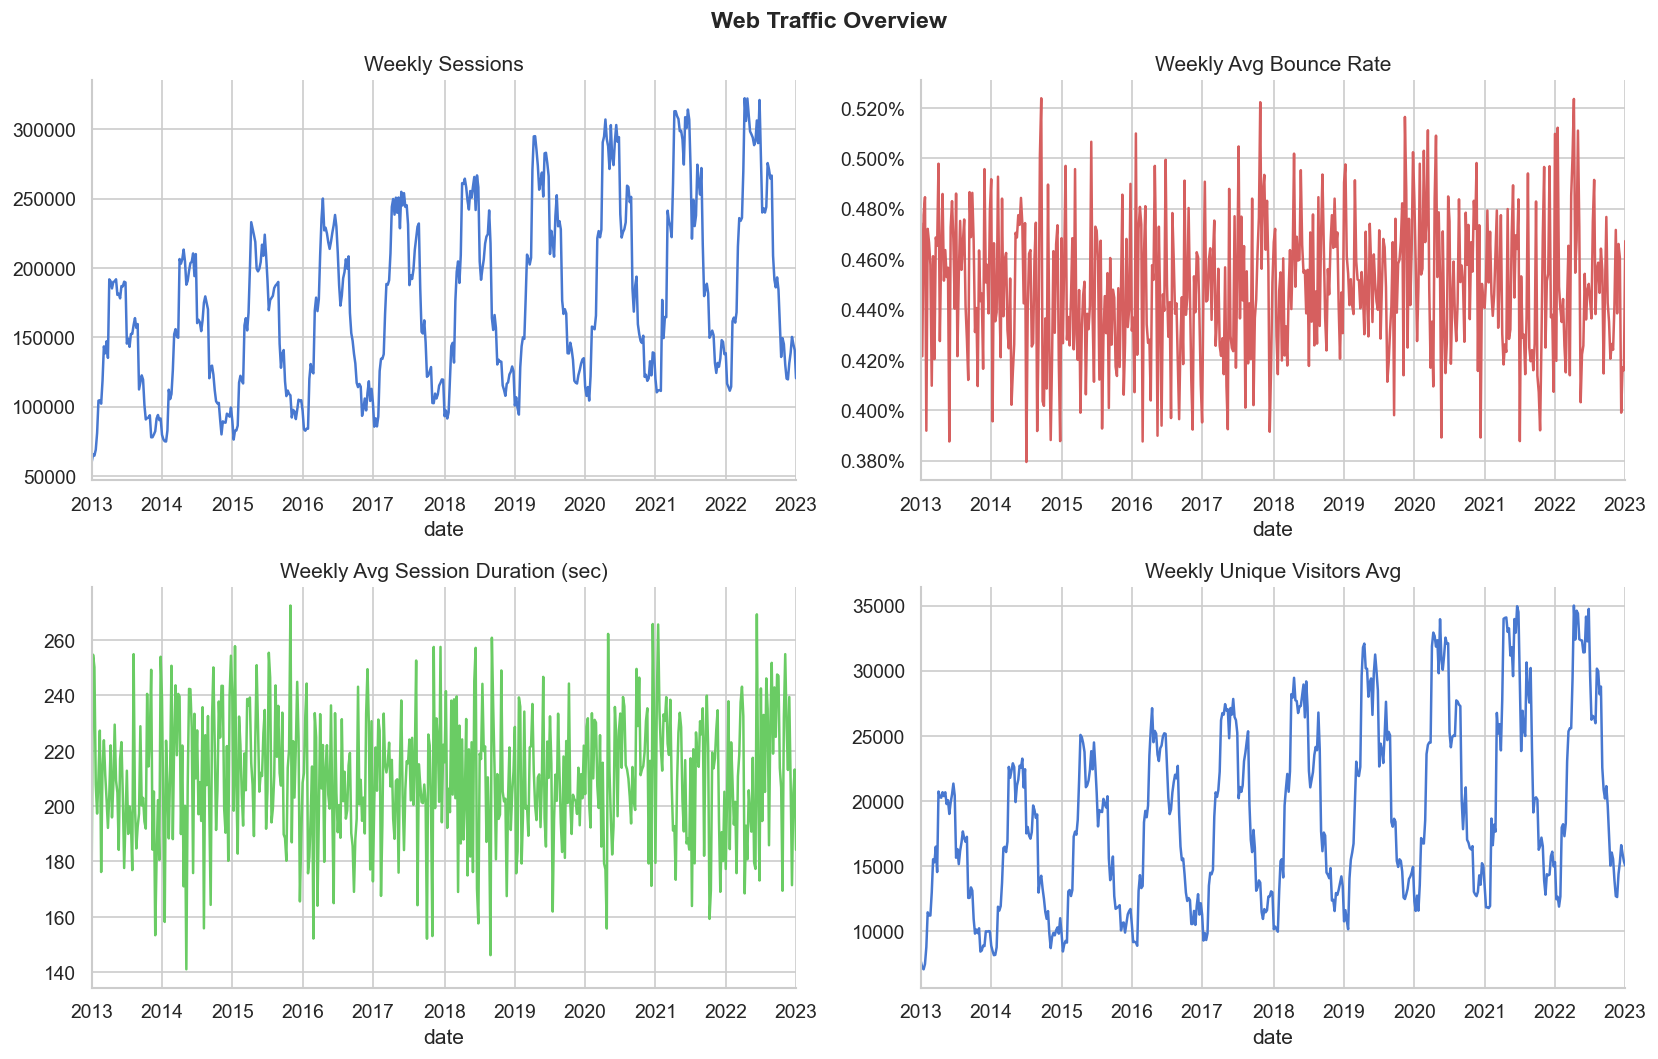

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

wt_daily = web_traffic.set_index('date')

wt_daily['sessions'].resample('W').sum().plot(
    ax=axes[0,0], color=PALETTE[0], linewidth=1.5)
axes[0,0].set_title('Weekly Sessions')

wt_daily['bounce_rate'].resample('W').mean().plot(
    ax=axes[0,1], color=PALETTE[3], linewidth=1.5)
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[0,1].set_title('Weekly Avg Bounce Rate')

wt_daily['avg_session_duration_sec'].resample('W').mean().plot(
    ax=axes[1,0], color=PALETTE[2], linewidth=1.5)
axes[1,0].set_title('Weekly Avg Session Duration (sec)')

wt_daily['unique_visitors'].resample('W').mean().plot(
    ax=axes[1,1], color=PALETTE)
axes[1,1].set_title('Weekly Unique Visitors Avg')

plt.suptitle('Web Traffic Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Lưu lượng truy cập có tính chu kỳ tương tự doanh thu nhưng có xu hướng tăng dần đều, mặc dù doanh thu giảm từ giai đoạn 2019 trở đi. Organic search cao cho thấy SEO hoạt động hiệu quả.

In [42]:
from scipy.signal import correlate
from sklearn.metrics import r2_score, mean_absolute_error

daily_rev = (
    orders_full
    .groupby('order_date')['revenue']
    .sum()
    .rename('revenue')
)
daily_sessions = (
    web_traffic
    .set_index('date')['sessions']
    .rename('sessions')
)
daily_unique_visitors = (
    web_traffic
    .set_index('date')['unique_visitors']
    .rename('unique_visitors')
)

daily = (
    pd.concat([daily_sessions, daily_rev, daily_unique_visitors], axis=1)
    .dropna()
    .sort_index()
)

# Smooth với 7-day rolling để giảm noise ngày lẻ
daily['sessions_7d'] = daily['sessions'].rolling(7, center=True).mean()
daily['revenue_7d']  = daily['revenue'].rolling(7, center=True).mean()
daily['unique_visitors_7d'] = daily['unique_visitors'].rolling(7, center=True).mean()
daily_smooth = daily.dropna()

print(f'Date range : {daily.index.min().date()} → {daily.index.max().date()}')
print(f'Days       : {len(daily):,}')
print(f'Pearson r (raw, lag=0)  : {daily["sessions"].corr(daily["revenue"]):.3f}')
print(f'Pearson r (7d MA, lag=0): {daily_smooth["sessions_7d"].corr(daily_smooth["revenue_7d"]):.3f}')

Date range : 2013-01-01 → 2022-12-31
Days       : 3,652
Pearson r (raw, lag=0)  : 0.328
Pearson r (7d MA, lag=0): 0.390


In [43]:
MAX_LAG = 30

# Pearson r at each lag
lags, pearson_r, r2_scores = [], [], []

for lag in range(0, MAX_LAG + 1):
    shifted = daily['sessions'].shift(lag)
    aligned = pd.concat([shifted, daily['revenue']], axis=1).dropna()
    r   = aligned.iloc[:,0].corr(aligned.iloc[:,1])
    # Simple OLS R² at this lag
    X = aligned.iloc[:,0].values.reshape(-1,1)
    y = aligned.iloc[:,1].values
    reg = LinearRegression().fit(X, y)
    lags.append(lag)
    pearson_r.append(r)
    r2_scores.append(reg.score(X, y))

lag_df = pd.DataFrame({'lag': lags, 'pearson_r': pearson_r, 'r2': r2_scores})
best_lag_r  = lag_df.loc[lag_df['pearson_r'].idxmax(), 'lag']
best_lag_r2 = lag_df.loc[lag_df['r2'].idxmax(),       'lag']

print(f'Best lag by Pearson r : {best_lag_r}  days  (r = {lag_df.loc[lag_df["pearson_r"].idxmax(), "pearson_r"]:.3f})')
print(f'Best lag by R²        : {best_lag_r2} days  (R²= {lag_df.loc[lag_df["r2"].idxmax(), "r2"]:.3f})')

Best lag by Pearson r : 1  days  (r = 0.328)
Best lag by R²        : 1 days  (R²= 0.108)


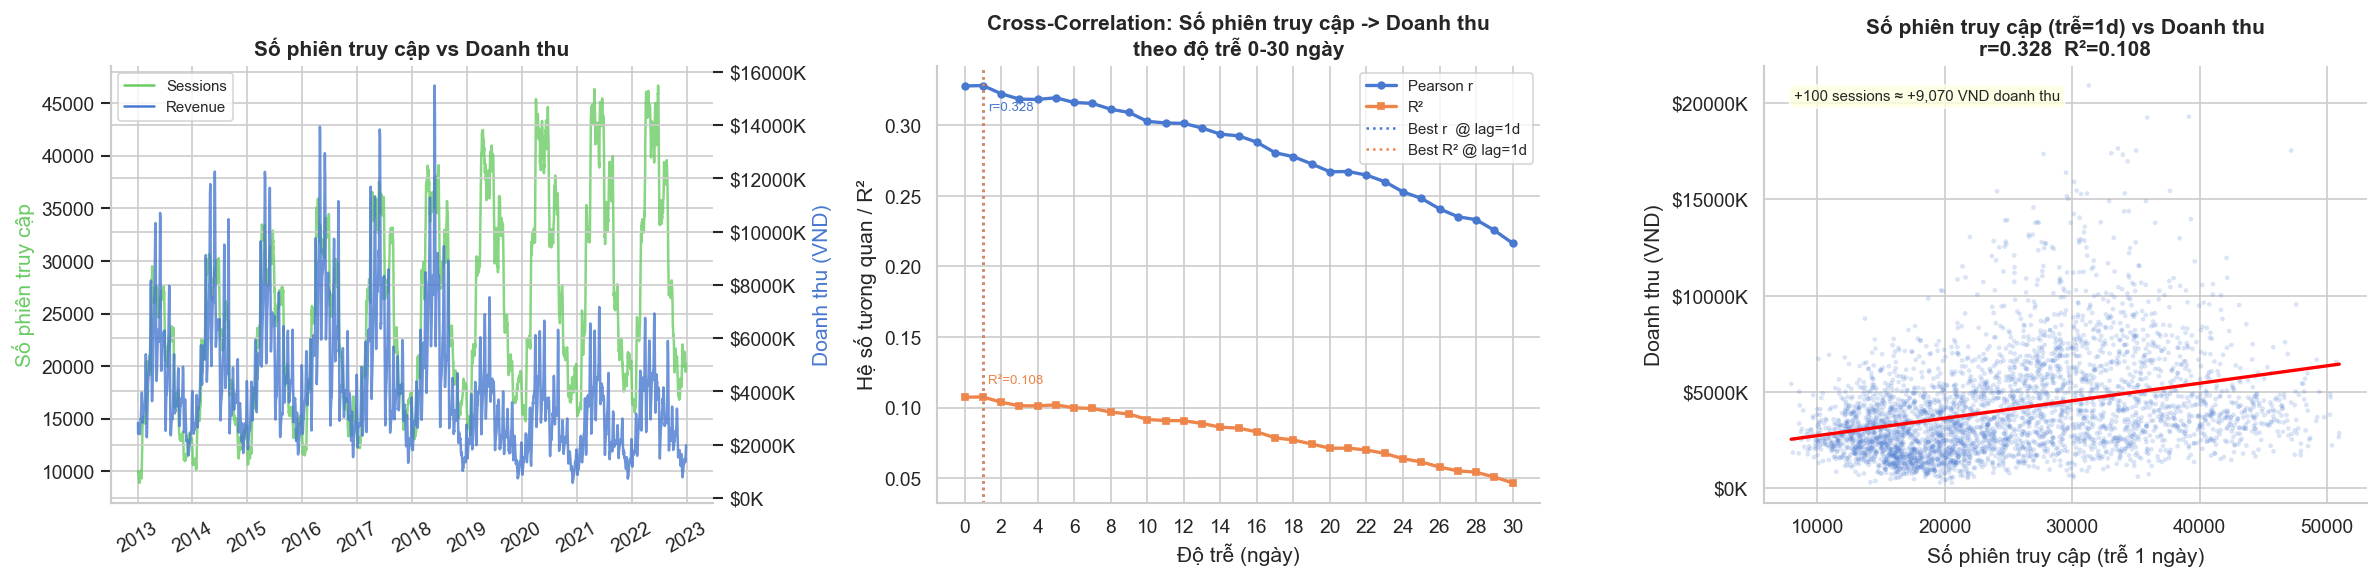

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# - 3c: Time series overlay (7d MA) -
ax1  = axes[0]
ax1b = ax1.twinx()

ax1.plot(daily_smooth.index, daily_smooth['sessions_7d'],
         color=PALETTE[2], linewidth=1.5, alpha=0.8, label='Sessions (7d MA)')
ax1b.plot(daily_smooth.index, daily_smooth['revenue_7d'],
          color=PALETTE[0], linewidth=1.5, alpha=0.8, label='Revenue (7d MA)')

ax1.set_ylabel('Số phiên truy cập',    color=PALETTE[2])
ax1b.set_ylabel('Doanh thu (VND)', color=PALETTE[0])
ax1b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax1.set_title('Số phiên truy cập vs Doanh thu', fontweight='bold')

lines = [plt.Line2D([0],[0], color=PALETTE[2], label='Sessions'),
         plt.Line2D([0],[0], color=PALETTE[0], label='Revenue')]
ax1.legend(handles=lines, fontsize=9)
ax1.tick_params(axis='x', rotation=30)

# Pearson r & R² across lags -
axes[1].plot(lag_df['lag'], lag_df['pearson_r'],
             marker='o', markersize=4, color=PALETTE[0],
             linewidth=2, label='Pearson r')
axes[1].plot(lag_df['lag'], lag_df['r2'],
             marker='s', markersize=4, color=PALETTE[1],
             linewidth=2, linestyle='-', label='R²')

axes[1].axvline(best_lag_r, color=PALETTE[0], linestyle=':',
                linewidth=1.5, label=f'Best r  @ lag={best_lag_r}d')
axes[1].axvline(best_lag_r2, color=PALETTE[1], linestyle=':',
                linewidth=1.5, label=f'Best R² @ lag={best_lag_r2}d')

# Annotate peaks
axes[1].annotate(f'r={lag_df.loc[lag_df["pearson_r"].idxmax(),"pearson_r"]:.3f}',
                 (best_lag_r, lag_df.loc[lag_df['pearson_r'].idxmax(),'pearson_r']),
                 xytext=(3, -15), textcoords='offset points', fontsize=8,
                 color=PALETTE[0])
axes[1].annotate(f'R²={lag_df.loc[lag_df["r2"].idxmax(),"r2"]:.3f}',
                 (best_lag_r2, lag_df.loc[lag_df['r2'].idxmax(),'r2']),
                 xytext=(3, 8), textcoords='offset points', fontsize=8,
                 color=PALETTE[1])

axes[1].set_xlabel('Độ trễ (ngày)')
axes[1].set_ylabel('Hệ số tương quan / R²')
axes[1].set_title('Cross-Correlation: Số phiên truy cập -> Doanh thu\ntheo độ trễ 0-30 ngày',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(0, MAX_LAG+1, 2))

# - 3b: Scatter at best lag -
best_lag = best_lag_r   # dùng best Pearson r
shifted_best = daily['sessions'].shift(best_lag)
scatter_df = pd.concat([shifted_best, daily['revenue']], axis=1).dropna()
scatter_df.columns = ['sessions_lag', 'revenue']

axes[2].scatter(scatter_df['sessions_lag'], scatter_df['revenue'],
                alpha=0.2, s=8, color=PALETTE[0], edgecolors='none')

# Trend line
z = np.polyfit(scatter_df['sessions_lag'], scatter_df['revenue'], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_df['sessions_lag'].min(),
                     scatter_df['sessions_lag'].max(), 200)
axes[2].plot(x_line, p(x_line), color='red', linewidth=2)

r_val  = scatter_df['sessions_lag'].corr(scatter_df['revenue'])
r2_val = lag_df.loc[lag_df['lag'] == best_lag, 'r2'].values[0]
axes[2].set_xlabel(f'Số phiên truy cập (trễ {best_lag} ngày)')
axes[2].set_ylabel('Doanh thu (VND)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
axes[2].set_title(f'Số phiên truy cập (trễ={best_lag}d) vs Doanh thu\nr={r_val:.3f}  R²={r2_val:.3f}',
                  fontweight='bold')
axes[2].text(0.05, 0.92,
             f'+100 sessions ≈ +{z[0]*100:,.0f} VND doanh thu',
             transform=axes[2].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))


plt.tight_layout()
plt.show()

Tỷ lệ chuyển đổi từ lượt truy cập thành đơn hàng thấp. Khoảng 100 lượt truy cập mới chỉ tạo ra khoảng 9.000 đồng doanh thu thêm.

## 10. Tồn Kho

Stockout rate         : 67.2%
Overstock rate        : 80.4%
Reorder rate          : 0.0%
Avg fill rate         : 96.1%
Median DOS            : 378.4 days
Avg sell-through      : 11.8%


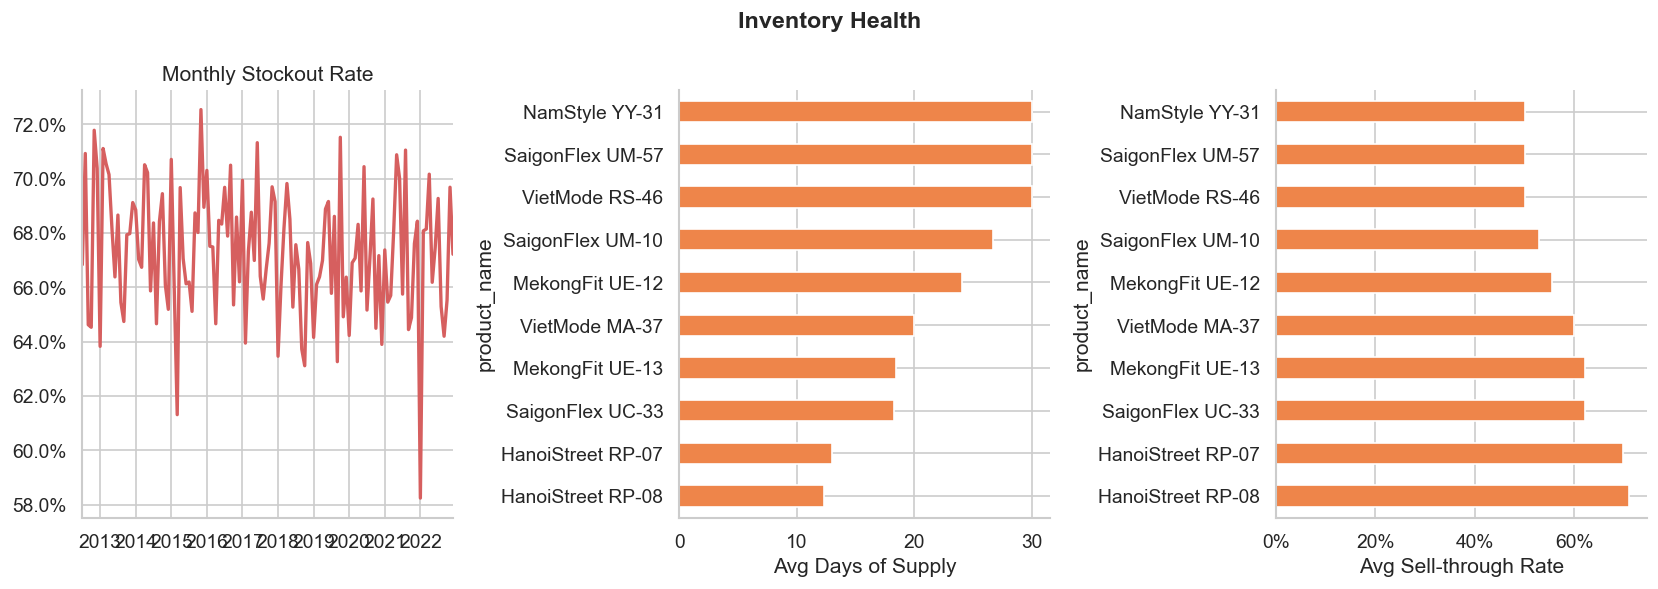

In [45]:
# Latest snapshot
latest_inv = inventory[inventory['snapshot_date'] == inventory['snapshot_date'].max()]

kpis = {
    'Stockout rate'   : f"{latest_inv['stockout_flag'].mean():.1%}",
    'Overstock rate'  : f"{latest_inv['overstock_flag'].mean():.1%}",
    'Reorder rate'    : f"{latest_inv['reorder_flag'].mean():.1%}",
    'Avg fill rate'   : f"{latest_inv['fill_rate'].mean():.1%}",
    'Median DOS'         : f"{latest_inv['days_of_supply'].median():.1f} days",
    'Avg sell-through': f"{latest_inv['sell_through_rate'].mean():.1%}",
}
for k, v in kpis.items():
    print(f'{k:<22}: {v}')
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Stockout trend
inv_monthly = inventory.groupby('snapshot_date')['stockout_flag'].mean()
inv_monthly.plot(ax=axes[0], color=PALETTE[3], linewidth=2)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[0].set_title('Monthly Stockout Rate')
axes[0].set_xlabel('')

# Days of supply
top_st = (
    latest_inv.merge(products[['product_id']], on='product_id')
    .set_index('product_name')['days_of_supply']
    .groupby('product_name')
    .median()
    .sort_values(ascending=True) )           

top_st.head(10).plot.barh(ax=axes[1], color=PALETTE[1])
axes[1].set_xlabel('Avg Days of Supply')
# latest_inv['days_of_supply'].clip(upper=90).plot.hist(
#     bins=40, ax=axes[1], color=PALETTE[0], edgecolor='white')
# axes[1].set_title('Days of Supply (capped @ 90)')
# axes[1].set_xlabel('Days')

# Sell-through by product line (top 20)
top_st = (
    latest_inv.merge(products[['product_id']], on='product_id')
    .set_index('product_name')['sell_through_rate']
    .groupby('product_name')
    .mean()
    .sort_values(ascending=False) )           

top_st.head(10).plot.barh(ax=axes[2], color=PALETTE[1])
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[2].set_xlabel('Avg Sell-through Rate')

plt.suptitle('Inventory Health', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Vừa thừa hàng vừa thiếu hàng nghiêm trọng. Avg DOS = 378.4 ngày, trung bình mất hơn 1 năm để bán hết lượng hàng trong kho. Hàng không bán được chất đầy kho trong khi những mặt hàng khách muốn lại bị cháy hàng hơn 2/3 thời gian. Sell-through rate đạt khoảng 12% (nhập 100 món thì bán được 12 món). Các sản phẩm HNStr RP 07 và 08 có sell-through rate và thời gian đẩy hàng tốt nhất.

## 11. Phân Loại Dòng Sản Phẩm (Ma Trận BCG)

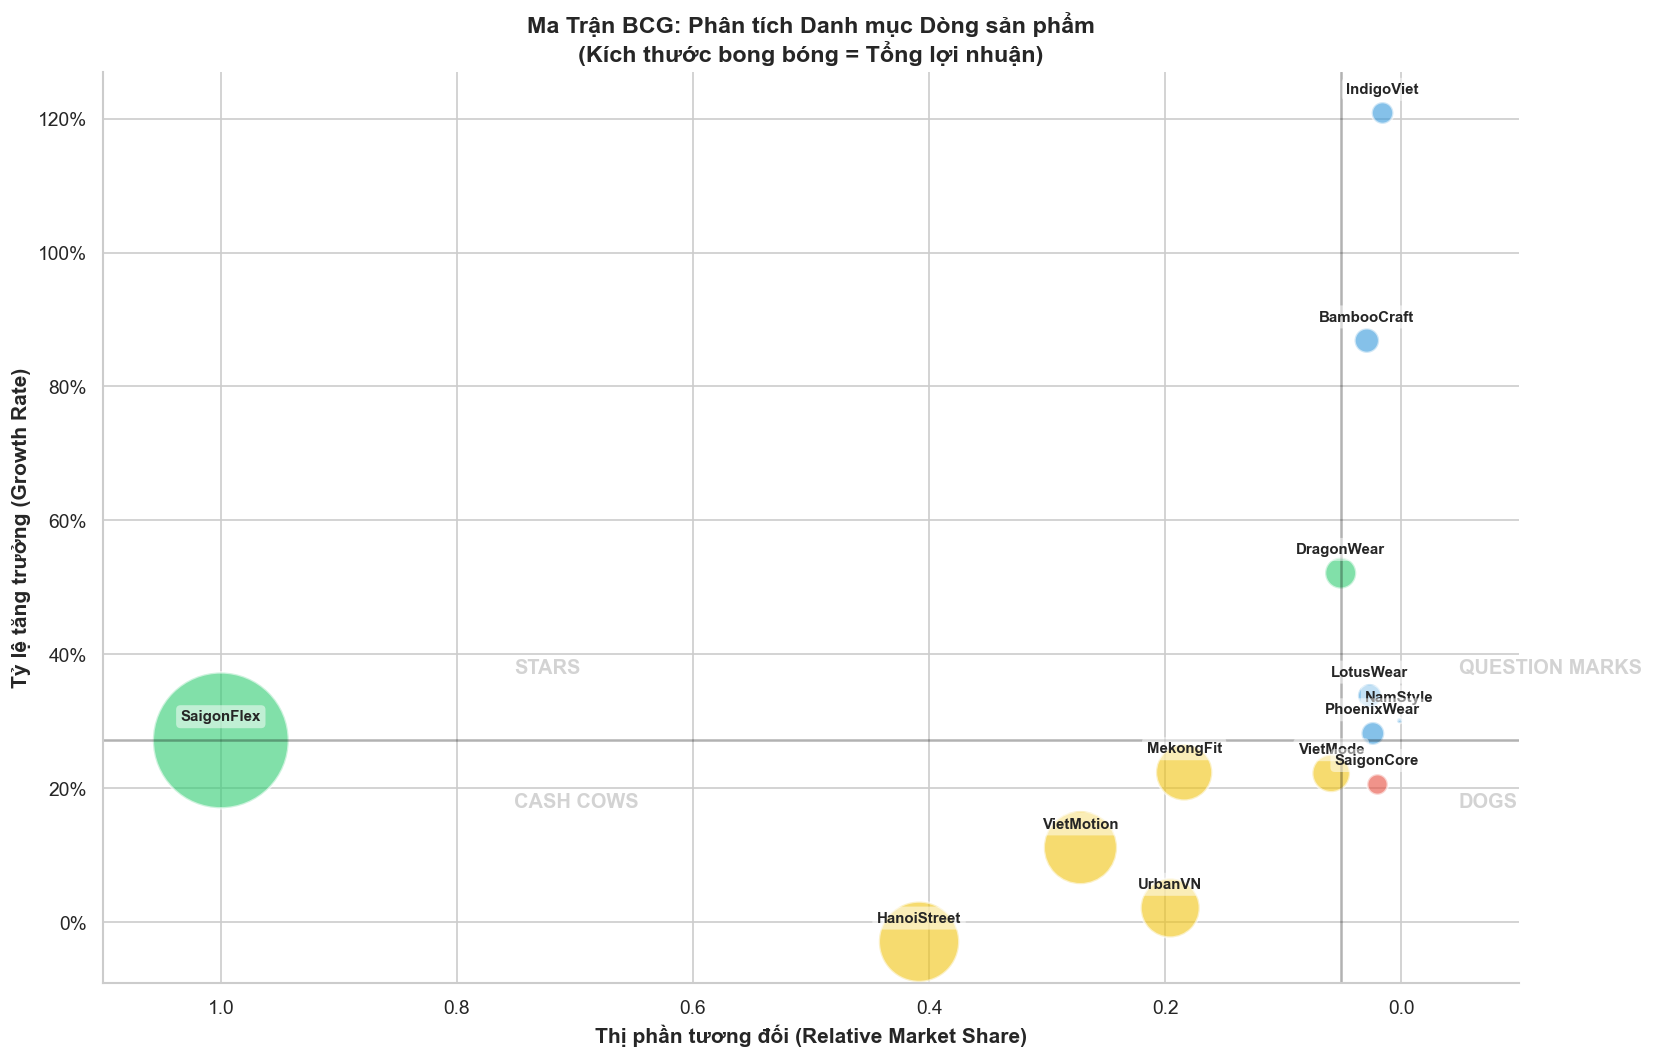

In [46]:
# 1. Chuẩn bị dữ liệu cấp Dòng sản phẩm (Product Line)
# Tính doanh thu theo năm/tháng để tính tăng trưởng (Growth)
order_items['year'] = pd.to_datetime(orders['order_date']).dt.year
line_yearly = (
    order_items.merge(products[['product_id', 'product_line']], on='product_id')
    .groupby(['product_line', 'year'])['line_rev'].sum()
    .unstack()
)

# Tính Growth Rate (ví dụ từ 2021 đến 2022)
growth_rate = ((line_yearly[2022] - line_yearly[2021]) / line_yearly[2021])

# Tính Market Share tương đối (So với dòng đứng đầu)
line_total_rev = order_items.merge(products[['product_id', 'product_line']], on='product_id').groupby('product_line')['line_rev'].sum()
relative_market_share = line_total_rev / line_total_rev.max()

# Tính Lợi nhuận tổng để làm kích thước bong bóng
line_profit = (
    order_items.merge(products[['product_id', 'product_line', 'cogs']], on='product_id')
    .assign(profit = lambda x: x['line_rev'] - (x['cogs'] * x['quantity']))
    .groupby('product_line')['profit'].sum()
)

# 2. Xây dựng BCG DataFrame
bcg_df = pd.DataFrame({
    'relative_share': relative_market_share,
    'growth_rate': growth_rate,
    'total_profit': line_profit
}).dropna()

# 3. Phân loại Quadrant theo chuẩn BCG
# Ngưỡng trung bình (Median) hoặc ngưỡng cố định (ví dụ 10% cho growth)
share_cutoff = bcg_df['relative_share'].median()
growth_cutoff = bcg_df['growth_rate'].median()

def classify_bcg(row):
    if row['growth_rate'] >= growth_cutoff and row['relative_share'] >= share_cutoff:
        return 'Stars'
    elif row['growth_rate'] < growth_cutoff and row['relative_share'] >= share_cutoff:
        return 'Cash Cows'
    elif row['growth_rate'] >= growth_cutoff and row['relative_share'] < share_cutoff:
        return 'Question Marks'
    else:
        return 'Dogs'

bcg_df['quadrant'] = bcg_df.apply(classify_bcg, axis=1)

# 4. Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(14, 9))
colors = {'Stars': '#2ecc71', 'Cash Cows': '#f1c40f', 'Question Marks': '#3498db', 'Dogs': '#e74c3c'}

for quad, grp in bcg_df.groupby('quadrant'):
    # Vẽ bong bóng
    scatter = ax.scatter(grp['relative_share'], grp['growth_rate'], 
                         s=grp['total_profit']/1e5, 
                         c=colors[quad], label=quad, alpha=0.6, 
                         edgecolors='white', linewidth=1.5)
    
    # Thêm tên dòng sản phẩm cho từng chấm
    for i, txt in enumerate(grp.index):
        ax.annotate(txt, 
                    (grp['relative_share'].iloc[i], grp['growth_rate'].iloc[i]),
                    xytext=(0, 10), # Đẩy chữ lên trên bong bóng 10 đơn vị
                    textcoords='offset points',
                    ha='center', 
                    va='bottom',
                    fontsize=9,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.5))

# Đảo ngược trục X theo đúng chuẩn BCG (Thị phần cao bên trái)
ax.set_xlim(1.1, -0.1) 

# Thêm đường phân cách trung bình
ax.axhline(growth_cutoff, color='black', linestyle='-', alpha=0.3)
ax.axvline(share_cutoff, color='black', linestyle='-', alpha=0.3)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_xlabel('Thị phần tương đối (Relative Market Share)', fontweight='bold')
ax.set_ylabel('Tỷ lệ tăng trưởng (Growth Rate)', fontweight='bold')
ax.set_title('Ma Trận BCG: Phân tích Danh mục Dòng sản phẩm\n(Kích thước bong bóng = Tổng lợi nhuận)', fontsize=14, fontweight='bold')

# Chú thích các vùng
ax.text(share_cutoff + 0.7, growth_cutoff + 0.1, 'STARS', fontsize=12, fontweight='bold', alpha=0.2)
ax.text(share_cutoff - 0.1, growth_cutoff + 0.1, 'QUESTION MARKS', fontsize=12, fontweight='bold', alpha=0.2)
ax.text(share_cutoff + 0.7, growth_cutoff - 0.1, 'CASH COWS', fontsize=12, fontweight='bold', alpha=0.2)
ax.text(share_cutoff - 0.1, growth_cutoff - 0.1, 'DOGS', fontsize=12, fontweight='bold', alpha=0.2)


plt.tight_layout()
plt.show()

In [47]:
bcg_df

,relative_share,growth_rate,total_profit,quadrant
product_line,,,,
BambooCraft,0.029235,0.868458,2.187252e+07,Question Marks
DragonWear,0.051382,0.521165,3.518004e+07,Stars
HanoiStreet,0.408546,-0.029556,2.331058e+08,Cash Cows
IndigoViet,0.015912,1.208441,1.715030e+07,Question Marks
LotusWear,0.026787,0.337894,2.020379e+07,Question Marks
MekongFit,0.183980,0.223436,1.146828e+08,Cash Cows
NamStyle,0.001522,0.300871,9.992349e+05,Question Marks
PhoenixWear,0.024126,0.281626,1.900830e+07,Question Marks
SaigonCore,0.020559,0.205849,1.534424e+07,Dogs


- CASH COWS (Bò sữa): HanoiStreet, VietMotion, MekongFit, UrbanVN tạo ra lợi nhuận cao nhưng ở vùng tăng trưởng thấp. Tuy nhiên, HanoiStreet có mức tăng trưởng gần như đi ngang (-2.955%), cho thấy dòng này đang dần bão hòa.
- STARS (Ngôi sao): 
    - SaigonFlex - dòng đứng đầu với thị phần cao nhất và bong bóng lợi nhuận khổng lồ, đây là nguồn dòng tiền chính + tăng trưởng đạt ~ 27%. 
    - DragonWear đang xuất hiện ở vùng này với mức tăng trưởng ấn tượng (>50%) nhưng thị trường tương đối nhỏ. 
- QUESTION MARKS (Dấu hỏi):
    - IndigoViet và BambooCraft đang có tốc độ tăng trưởng từ 80% đến hơn 120% nhưng thị phần còn rất nhỏ. Đây là những dòng tiềm năng nhất để đầu tư Marketing nhằm chiếm lĩnh thị phần.

- DOGS (Chó mực): SaigonCore nằm sát vùng nguy hiểm với thị phần thấp và tăng trưởng thấp.


## 12. Phân Tích Khuyến Mãi

In [50]:
import matplotlib.dates as mdates
from scipy import stats as scipy_stats

PROMO2_FIXED = 50
oi = order_items.copy()

# Group 1: only promo_id applied
single = oi[oi['promo_id'].notna() & oi['promo_id_2'].isna()].copy()
single['applied_promo']       = single['promo_id']
single['attributed_discount'] = single['discount_amount']
single['stack_flag']          = False

# Group 2a: stacked - attribute promo_id portion
stack_p1 = oi[oi['promo_id'].notna() & oi['promo_id_2'].notna()].copy()
stack_p1['applied_promo']       = stack_p1['promo_id']
stack_p1['attributed_discount'] = stack_p1['discount_amount'] - PROMO2_FIXED
stack_p1['stack_flag']          = True

# Group 2b: stacked - attribute promo_id_2 fixed $50
stack_p2 = oi[oi['promo_id_2'].notna()].copy()
stack_p2['applied_promo']       = stack_p2['promo_id_2']
stack_p2['attributed_discount'] = PROMO2_FIXED
stack_p2['stack_flag']          = True

promo_long = (
    pd.concat([single, stack_p1, stack_p2], ignore_index=True)
    .merge(
        promotions[['promo_id','promo_name','promo_type',
                    'promo_channel','discount_value',
                    'start_date','end_date','stackable_flag']],
        left_on='applied_promo', right_on='promo_id',
        how='left'
    )
)

# Sanity check
n_single  = len(single)
n_stacked = len(stack_p1)
print(f'Single promo lines : {n_single:,}')
print(f'Stacked lines      : {n_stacked:,}  ({n_stacked/(n_single+n_stacked):.1%} of promo lines)')
print(f'promo_id_2 always  : ${stack_p2["attributed_discount"].mean():.2f} ')

Single promo lines : 276,110
Stacked lines      : 206  (0.1% of promo lines)
promo_id_2 always  : $50.00 


In [49]:
# Xem xét các promo trùng lặp
promo_meta = promotions.dropna(subset=['start_date','end_date']).copy()

# Find overlapping pairs
pairs = []
promo_list = promo_meta[['promo_id','promo_name','promo_type',
                          'start_date','end_date']].reset_index(drop=True)
for i, p1 in promo_list.iterrows():
    for j, p2 in promo_list.iterrows():
        if j <= i:
            continue
        if p1['start_date'] <= p2['end_date'] and p2['start_date'] <= p1['end_date']:
            days = (min(p1['end_date'], p2['end_date']) -
                    max(p1['start_date'], p2['start_date'])).days
            pairs.append({'promo_1': p1['promo_name'],
                          'promo_2': p2['promo_name'],
                          'overlap_days': days,
                          'type_1': p1['promo_type'],
                          'type_2': p2['promo_type']})

overlap_df = pd.DataFrame(pairs)
print(f'Overlapping promo pairs : {len(overlap_df)}')
if not overlap_df.empty:
    print(f'Avg overlap             : {overlap_df["overlap_days"].mean():.0f} days')
    print(overlap_df.nlargest(10, 'overlap_days').to_string(index=False))

# # - Gantt chart -
# type_colors = {t: PALETTE[i % len(PALETTE)]
#                for i, t in enumerate(promo_meta['promo_type'].unique())}

# fig, ax = plt.subplots(figsize=(16, max(5, len(promo_meta) * 0.45)))
# promo_sorted = promo_meta.sort_values('start_date').reset_index(drop=True)

# for i, row in promo_sorted.iterrows():
#     duration = (row['end_date'] - row['start_date']).days
#     color    = type_colors.get(row['promo_type'], 'gray')
#     ax.barh(i, duration, left=row['start_date'],
#             height=0.6, color=color, alpha=0.75, edgecolor='white')
#     ax.text(row['start_date'], i, f"  {row['promo_name']}",
#             va='center', fontsize=7.5)

# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
# ax.set_yticks([])
# ax.set_title('Promo Timeline - Gantt (colour = promo_type)', fontweight='bold')
# ax.legend(handles=[mpatches.Patch(color=c, label=t)
#                    for t, c in type_colors.items()],
#           fontsize=9, loc='upper right', title='Type')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

Overlapping promo pairs : 5
Avg overlap             : 3 days
         promo_1            promo_2  overlap_days     type_1 type_2
Fall Launch 2013 Urban Blowout 2013             3 percentage  fixed
Fall Launch 2015 Urban Blowout 2015             3 percentage  fixed
Fall Launch 2017 Urban Blowout 2017             3 percentage  fixed
Fall Launch 2019 Urban Blowout 2019             3 percentage  fixed
Fall Launch 2021 Urban Blowout 2021             3 percentage  fixed


In [ ]:

promo_perf = (
    promo_long
    .groupby(['applied_promo','promo_name','promo_type','promo_channel'])
    .agg(
        n_lines         = ('order_id',             'count'),
        n_orders        = ('order_id',             'nunique'),
        total_rev       = ('line_rev',             'sum'),
        attributed_disc = ('attributed_discount',  'sum'),
        n_stacked       = ('stack_flag',           'sum'),
    )
    .assign(
        rev_net    = lambda x: x['total_rev'] - x['attributed_disc'],
        disc_pct   = lambda x: x['attributed_disc'] / x['total_rev'],
        roi        = lambda x: x['rev_net'] / x['attributed_disc'],
        stack_rate = lambda x: x['n_stacked'] / x['n_lines'],
        aov        = lambda x: x['total_rev'] / x['n_orders'],
    )
    .reset_index()
    .sort_values('total_rev', ascending=False)
)

print('=== Per-Promo Performance ===')
print(promo_perf[['promo_name','promo_type','promo_channel',
                   'n_orders','total_rev','attributed_disc',
                   'disc_pct','roi','stack_rate']]
                   .query('promo_type != "fixed"')
                   .sort_values('roi', ascending=False)
      .head(10).to_string(index=False))

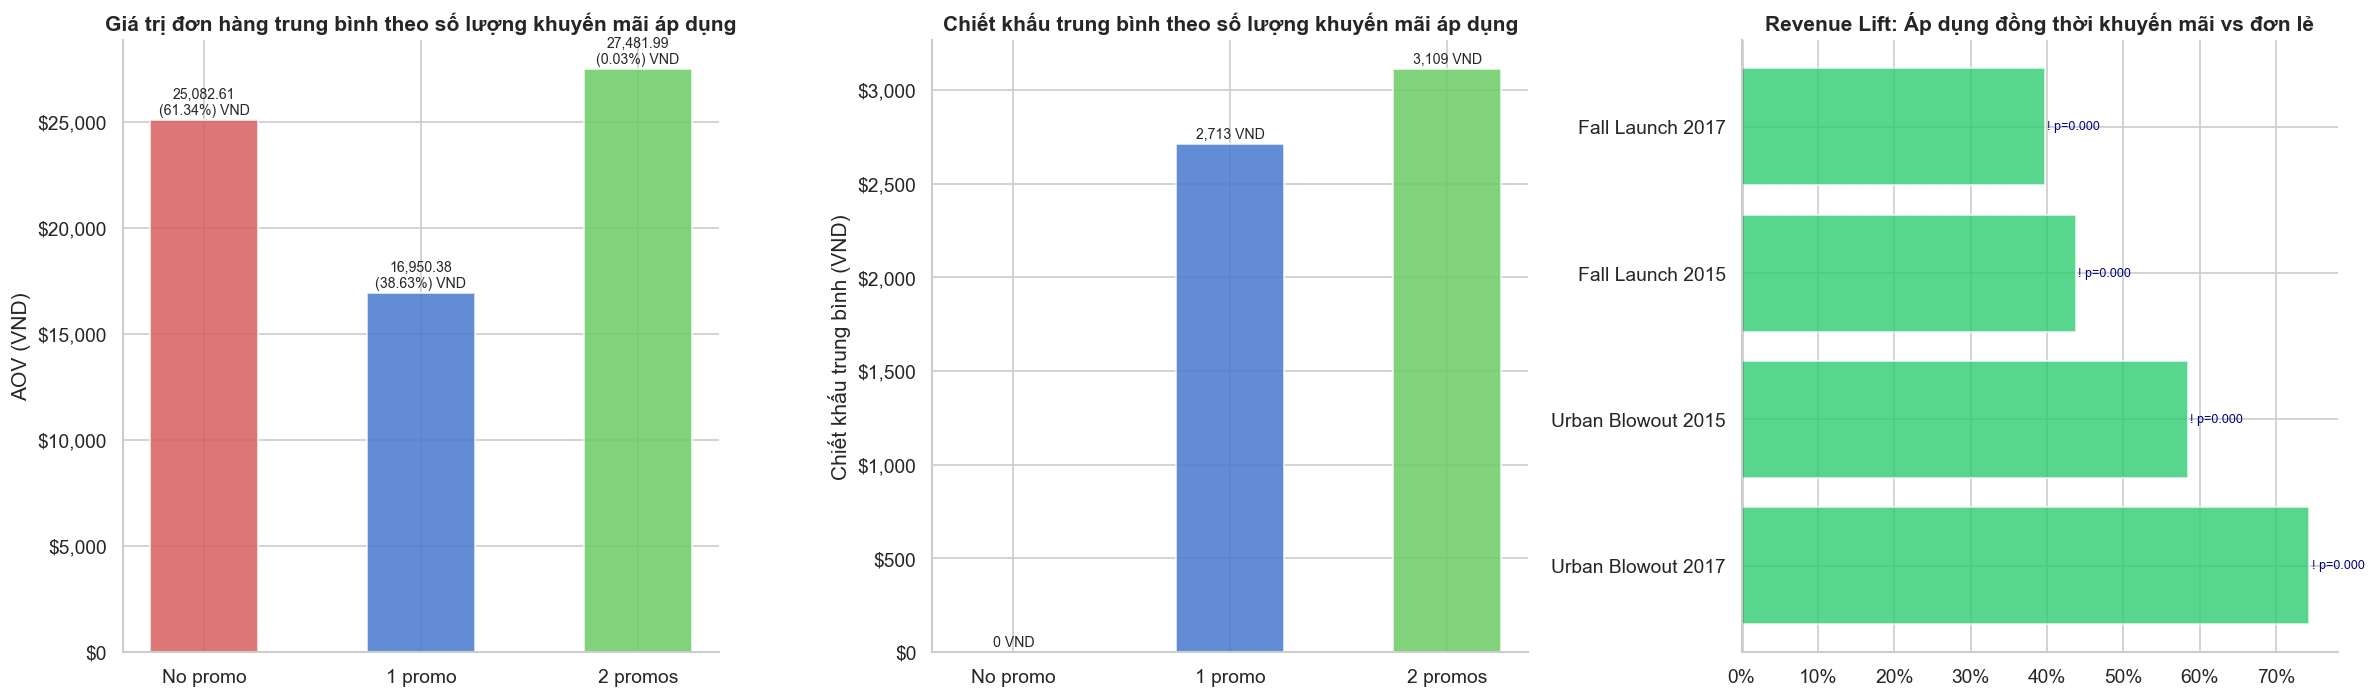


=== Stack Summary ===
          n_lines       avg_rev  avg_discount     total_rev  pct_lines
No promo   438353  25082.613905      0.000000  1.099504e+10   0.613365
1 promo    276110  16950.378195   2712.566888  4.680169e+09   0.386347
2 promos      206  27481.985437   3109.109806  5.661289e+06   0.000288

=== T-test Results ===
        promo_name  mean_single  mean_stacked  n_single  n_stacked  lift_pct      p_value  significant
Urban Blowout 2017 17105.122505  29819.060405      5385         74  0.743282 1.688970e-07         True
Urban Blowout 2015 16516.332778  26171.807045      5072        132  0.584602 3.860369e-07         True
  Fall Launch 2015 18200.126465  26171.807045      7366        132  0.438001 2.172871e-05         True
  Fall Launch 2017 21338.940654  29819.060405      5339         74  0.397401 2.570956e-04         True


In [51]:
# 4a: line revenue by number of promos applied
stack_summary = (
    oi.assign(n_promos=lambda x:
              x['promo_id'].notna().astype(int) +
              x['promo_id_2'].notna().astype(int))
    .groupby('n_promos')
    .agg(n_lines      = ('order_id',        'count'),
         avg_rev      = ('line_rev',        'mean'),
         avg_discount = ('discount_amount', 'mean'),
         total_rev    = ('line_rev',        'sum'))
    .assign(pct_lines=lambda x: x['n_lines'] / x['n_lines'].sum())
)
stack_summary.index = ['No promo','1 promo','2 promos']

# 4b: t-test stacked vs single per promo
ttest_rows = []
for promo, grp in promo_long.groupby('promo_name'):
    s = grp[~grp['stack_flag']]['line_rev']
    t = grp[ grp['stack_flag']]['line_rev']
    if len(s) < 5 or len(t) < 5:
        continue
    _, p = scipy_stats.ttest_ind(s, t, equal_var=False)
    ttest_rows.append({
        'promo_name'   : promo,
        'mean_single'  : s.mean(),
        'mean_stacked' : t.mean(),
        'n_single'     : len(s),
        'n_stacked'    : len(t),
        'lift_pct'     : (t.mean() - s.mean()) / s.mean(),
        'p_value'      : p,
        'significant'  : p < 0.05,
    })
ttest_df = pd.DataFrame(ttest_rows).sort_values('lift_pct', ascending=False)


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot A: avg rev by n_promos
clrs = [PALETTE[3], PALETTE[0], PALETTE[2]]
bars = axes[0].bar(stack_summary.index, stack_summary['avg_rev'],
                   color=clrs, alpha=0.85, width=0.5)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
axes[0].set_title('Giá trị đơn hàng trung bình theo số lượng khuyến mãi áp dụng', fontweight='bold')
axes[0].set_ylabel('AOV (VND)')
for bar, (_, row) in zip(bars, stack_summary.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + stack_summary['avg_rev'].max() * 0.01,
                 f"{row['avg_rev']:,.2f}\n({row['pct_lines']:.2%}) VND",
                 ha='center', fontsize=8.5)

# Plot B: avg discount by n_promos
bars2 = axes[1].bar(stack_summary.index, stack_summary['avg_discount'],
                    color=clrs, alpha=0.85, width=0.5)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
axes[1].set_title('Chiết khấu trung bình theo số lượng khuyến mãi áp dụng', fontweight='bold')
axes[1].set_ylabel('Chiết khấu trung bình (VND)')
for bar, (_, row) in zip(bars2, stack_summary.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + stack_summary['avg_discount'].max() * 0.01,
                 f"{row['avg_discount']:,.0f} VND",
                 ha='center', fontsize=8.5)

# Plot C: lift % per promo
if not ttest_df.empty:
    lift_colors = ['#2ecc71' if v > 0 else '#e74c3c'
                   for v in ttest_df['lift_pct']]
    axes[2].barh(ttest_df['promo_name'], ttest_df['lift_pct'],
                 color=lift_colors, alpha=0.8)
    axes[2].axvline(0, color='black', linewidth=0.8)
    axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(1))
    axes[2].set_title('Revenue Lift: Áp dụng đồng thời khuyến mãi vs đơn lẻ',
                      fontweight='bold')
    for i, (_, row) in enumerate(ttest_df.iterrows()):
        sig_label = '! ' if row['significant'] else ''
        x_pos     = row['lift_pct']
        axes[2].text(x_pos + (0.003 if x_pos >= 0 else -0.003), i,
                     f"{sig_label}p={row['p_value']:.3f}",
                     va='center', fontsize=7.5,
                     color='navy' if row['significant'] else 'gray',
                     ha='left'   if x_pos >= 0 else 'right')
else:
    axes[2].text(0.5, 0.5, 'Not enough data\nfor t-test',
                 ha='center', va='center', transform=axes[2].transAxes,
                 fontsize=11, color='gray')
    axes[2].set_title('Revenue Lift: Áp dụng đồng thời khuyến mãi vs đơn lẻ', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== Stack Summary ===')
print(stack_summary.to_string())
print('\n=== T-test Results ===')
print(ttest_df.to_string(index=False))

In [58]:
promo_perf = (
    promo_long
    .groupby(['applied_promo','promo_name','promo_type','promo_channel'])
    .agg(
        n_lines         = ('order_id',             'count'),
        n_orders        = ('order_id',             'nunique'),
        total_rev       = ('line_rev',             'sum'),
        attributed_disc = ('attributed_discount',  'sum'),
        n_stacked       = ('stack_flag',           'sum'),
    )
    .assign(
        gross_rev    = lambda x: x['total_rev'] + x['attributed_disc'],
        disc_pct   = lambda x: x['attributed_disc'] / x['total_rev'],
        roi        = lambda x: x['total_rev'] / x['attributed_disc'],
        aov        = lambda x: x['total_rev'] / x['n_orders'],
    )
    .reset_index()
    .sort_values('total_rev', ascending=False)
)

print('=== Per-Promo Performance ===')
print(promo_perf[['promo_name','promo_type','promo_channel',
                   'n_orders','total_rev','attributed_disc',
                   'disc_pct','roi',]]
                   .query('promo_type != "fixed"')
                   .sort_values('roi', ascending=False)
      .head(10).to_string(index=False))

=== Per-Promo Performance ===
      promo_name promo_type promo_channel  n_orders    total_rev  attributed_disc  disc_pct      roi
Fall Launch 2020 percentage  all_channels      2469  68214466.80       7579385.50  0.111111 9.000000
Fall Launch 2014 percentage  all_channels      5064 102386562.04      11376285.26  0.111111 9.000000
Fall Launch 2022 percentage  all_channels      2466  72106194.48       8011799.83  0.111111 9.000000
Fall Launch 2019 percentage         email      2873  72746607.20       8082956.82  0.111111 8.999999
Fall Launch 2021 percentage         email      2336  67280170.93       7475575.01  0.111111 8.999999
Fall Launch 2018 percentage         email      4049 103549647.81      11505517.14  0.111111 8.999999
Fall Launch 2013 percentage         email      5632 117265398.84      13029489.80  0.111111 8.999999
Fall Launch 2016 percentage        online      5279 122066567.29      13562953.08  0.111111 8.999999
Fall Launch 2017 percentage  all_channels      4969 116135214

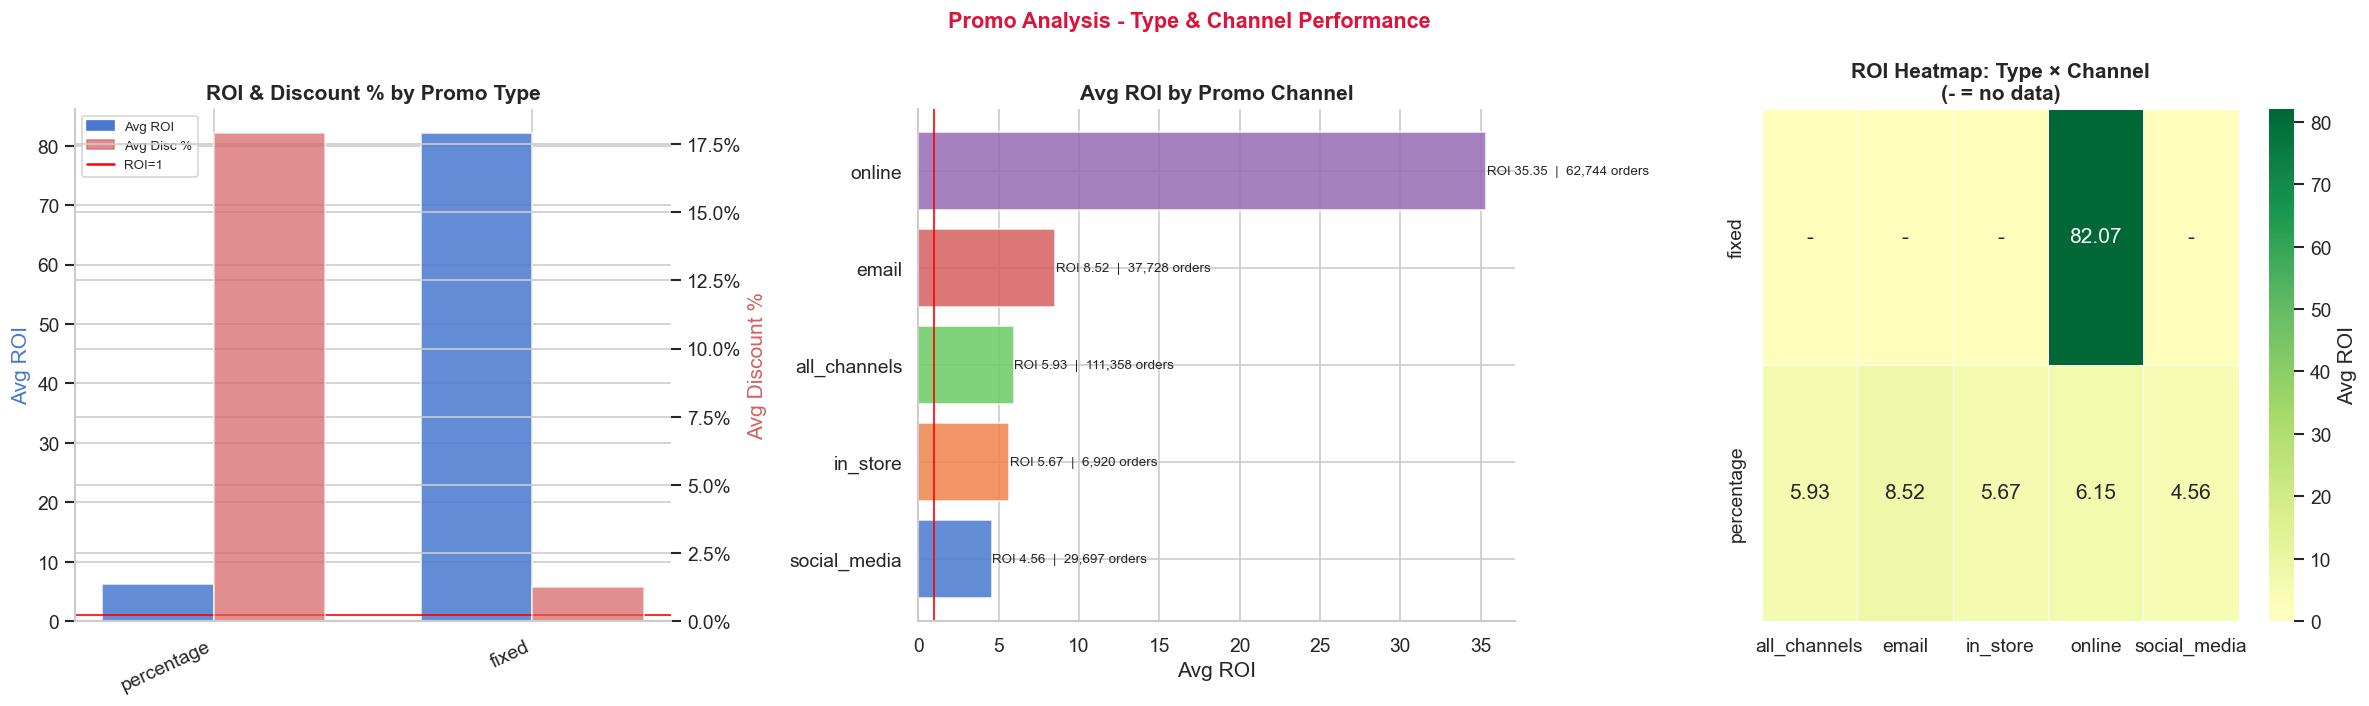

In [59]:
# Performance by type & channel
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# - ROI & disc_pct by promo_type -
type_perf = (
    promo_perf.groupby('promo_type')
    .agg(avg_roi      = ('roi',      'mean'),
         avg_disc_pct = ('disc_pct', 'mean'),
         total_rev    = ('total_rev','sum'),
         n_orders     = ('n_orders', 'sum'))
    .sort_values('avg_roi', ascending=True)
    .reset_index()
)

x  = np.arange(len(type_perf))
w  = 0.35
ax = axes[0]
ax.bar(x - w/2, type_perf['avg_roi'],
       width=w, color=PALETTE[0], alpha=0.85, label='Avg ROI')
ax.axhline(1.0, color='red', linestyle='-', linewidth=1, label='ROI = 1')
ax.set_xticks(x)
ax.set_xticklabels(type_perf['promo_type'], rotation=25, ha='right')
ax.set_ylabel('Avg ROI', color=PALETTE[0])
ax.set_title('ROI & Discount % by Promo Type', fontweight='bold')

ax0b = ax.twinx()
ax0b.bar(x + w/2, type_perf['avg_disc_pct'],
         width=w, color=PALETTE[3], alpha=0.7, label='Avg Disc %')
ax0b.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax0b.set_ylabel('Avg Discount %', color=PALETTE[3])

handles = [mpatches.Patch(color=PALETTE[0], label='Avg ROI'),
           mpatches.Patch(color=PALETTE[3], alpha=0.7, label='Avg Disc %'),
           plt.Line2D([0],[0], color='red', linestyle='-', label='ROI=1')]
ax.legend(handles=handles, fontsize=8, loc='upper left')

# - 5b: ROI by promo_channel -
ch_perf = (
    promo_perf.groupby('promo_channel')
    .agg(avg_roi  = ('roi',      'mean'),
         n_orders = ('n_orders', 'sum'),
         total_rev= ('total_rev','sum'))
    .sort_values('avg_roi', ascending=True)
    .reset_index()
)

axes[1].barh(ch_perf['promo_channel'], ch_perf['avg_roi'],
             color=[PALETTE[i % len(PALETTE)] for i in range(len(ch_perf))],
             alpha=0.85)
axes[1].axvline(1.0, color='red', linestyle='-', linewidth=1)
axes[1].set_title('Avg ROI by Promo Channel', fontweight='bold')
axes[1].set_xlabel('Avg ROI')
for bar, (_, row) in zip(axes[1].patches, ch_perf.iterrows()):
    axes[1].text(bar.get_width() + 0.02,
                 bar.get_y() + bar.get_height() / 2,
                 f"ROI {row['avg_roi']:.2f}  |  {row['n_orders']:,} orders",
                 va='center', fontsize=8)

# - 5c: Heatmap type × channel -
pivot_roi = (
    promo_perf
    .groupby(['promo_type','promo_channel'])['roi']
    .mean()
    .unstack('promo_channel')
)
annot_vals = pivot_roi.round(2).astype(object).where(pivot_roi.notna(), other='-')

sns.heatmap(pivot_roi.fillna(0),
            annot=annot_vals, fmt='',
            cmap='RdYlGn', center=1.0,
            linewidths=0.5,
            cbar_kws={'label': 'Avg ROI'},
            ax=axes[2])
axes[2].set_title('ROI Heatmap: Type × Channel\n(- = no data)', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.suptitle('Promo Analysis - Type & Channel Performance',
             fontsize=13, fontweight='bold', color='crimson')
plt.tight_layout()
plt.show()